# Enhancing Stock Price Prediction for Nifty 50 IT Sector Companies

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import yfinance as yf
import pandas as pd
import os
import numpy as np

## Data Preprocessing

### Loading data using the Yahoo Finance API

In [3]:
# Define the companies and their tickers
companies = {
    "Tata Consultancy Services": "TCS.NS",
    "Infosys": "INFY.NS",
    "Wipro": "WIPRO.NS",
    "HCL Technologies": "HCLTECH.NS",
    "Tech Mahindra": "TECHM.NS"
}

def fetch_and_save_data(ticker, period, interval, filename):
    # Download the data
    data = yf.download(ticker, period=period, interval=interval)
    
    # Save the data to a CSV file
    data.to_csv(filename)
    print(f"Data for {ticker} saved to {filename}")
    
    # Print the columns and the index of the data
    print(f"\nData columns for {ticker}:")
    print(data.columns)
    
    print(f"\nData index for {ticker}:")
    print(data.index)

# List to store the DataFrames for each company
dataframes = []

# Fetch data for each company
for company, ticker in companies.items():
    filename = f"{company}.csv"
    fetch_and_save_data(ticker, period="max", interval="1d", filename=filename)
    
    # Load the data into a DataFrame
    data = pd.read_csv(filename, index_col=0, parse_dates=True)
    
    # Add a column to identify the company
    data['Ticker'] = ticker
    
    # Append to the list of DataFrames
    dataframes.append(data)

# Concatenate all DataFrames along rows
all_data = pd.concat(dataframes, axis=0)

# Reset the index to have a flat structure
all_data.reset_index(inplace=True)

# Print the first few rows of the combined DataFrame
print(all_data.head())

[*********************100%***********************]  1 of 1 completed


Data for TCS.NS saved to Tata Consultancy Services.csv

Data columns for TCS.NS:
MultiIndex([('Adj Close', 'TCS.NS'),
            (    'Close', 'TCS.NS'),
            (     'High', 'TCS.NS'),
            (      'Low', 'TCS.NS'),
            (     'Open', 'TCS.NS'),
            (   'Volume', 'TCS.NS')],
           names=['Price', 'Ticker'])

Data index for TCS.NS:
DatetimeIndex(['2002-08-12 00:00:00+00:00', '2002-08-13 00:00:00+00:00',
               '2002-08-14 00:00:00+00:00', '2002-08-15 00:00:00+00:00',
               '2002-08-16 00:00:00+00:00', '2002-08-19 00:00:00+00:00',
               '2002-08-20 00:00:00+00:00', '2002-08-21 00:00:00+00:00',
               '2002-08-22 00:00:00+00:00', '2002-08-23 00:00:00+00:00',
               ...
               '2024-11-29 00:00:00+00:00', '2024-12-02 00:00:00+00:00',
               '2024-12-03 00:00:00+00:00', '2024-12-04 00:00:00+00:00',
               '2024-12-05 00:00:00+00:00', '2024-12-06 00:00:00+00:00',
               '2024-12-09 00:0

[*********************100%***********************]  1 of 1 completed


Data for INFY.NS saved to Infosys.csv

Data columns for INFY.NS:
MultiIndex([('Adj Close', 'INFY.NS'),
            (    'Close', 'INFY.NS'),
            (     'High', 'INFY.NS'),
            (      'Low', 'INFY.NS'),
            (     'Open', 'INFY.NS'),
            (   'Volume', 'INFY.NS')],
           names=['Price', 'Ticker'])

Data index for INFY.NS:
DatetimeIndex(['1996-01-01 00:00:00+00:00', '1996-01-02 00:00:00+00:00',
               '1996-01-03 00:00:00+00:00', '1996-01-04 00:00:00+00:00',
               '1996-01-05 00:00:00+00:00', '1996-01-08 00:00:00+00:00',
               '1996-01-09 00:00:00+00:00', '1996-01-10 00:00:00+00:00',
               '1996-01-11 00:00:00+00:00', '1996-01-12 00:00:00+00:00',
               ...
               '2024-11-29 00:00:00+00:00', '2024-12-02 00:00:00+00:00',
               '2024-12-03 00:00:00+00:00', '2024-12-04 00:00:00+00:00',
               '2024-12-05 00:00:00+00:00', '2024-12-06 00:00:00+00:00',
               '2024-12-09 00:00:00+00:0

[*********************100%***********************]  1 of 1 completed


Data for WIPRO.NS saved to Wipro.csv

Data columns for WIPRO.NS:
MultiIndex([('Adj Close', 'WIPRO.NS'),
            (    'Close', 'WIPRO.NS'),
            (     'High', 'WIPRO.NS'),
            (      'Low', 'WIPRO.NS'),
            (     'Open', 'WIPRO.NS'),
            (   'Volume', 'WIPRO.NS')],
           names=['Price', 'Ticker'])

Data index for WIPRO.NS:
DatetimeIndex(['1996-01-01 00:00:00+00:00', '1996-01-02 00:00:00+00:00',
               '1996-01-03 00:00:00+00:00', '1996-01-04 00:00:00+00:00',
               '1996-01-05 00:00:00+00:00', '1996-01-08 00:00:00+00:00',
               '1996-01-09 00:00:00+00:00', '1996-01-10 00:00:00+00:00',
               '1996-01-11 00:00:00+00:00', '1996-01-12 00:00:00+00:00',
               ...
               '2024-11-29 00:00:00+00:00', '2024-12-02 00:00:00+00:00',
               '2024-12-03 00:00:00+00:00', '2024-12-04 00:00:00+00:00',
               '2024-12-05 00:00:00+00:00', '2024-12-06 00:00:00+00:00',
               '2024-12-09 00:00:

[*********************100%***********************]  1 of 1 completed


Data for HCLTECH.NS saved to HCL Technologies.csv

Data columns for HCLTECH.NS:
MultiIndex([('Adj Close', 'HCLTECH.NS'),
            (    'Close', 'HCLTECH.NS'),
            (     'High', 'HCLTECH.NS'),
            (      'Low', 'HCLTECH.NS'),
            (     'Open', 'HCLTECH.NS'),
            (   'Volume', 'HCLTECH.NS')],
           names=['Price', 'Ticker'])

Data index for HCLTECH.NS:
DatetimeIndex(['2002-08-12 00:00:00+00:00', '2002-08-13 00:00:00+00:00',
               '2002-08-14 00:00:00+00:00', '2002-08-15 00:00:00+00:00',
               '2002-08-16 00:00:00+00:00', '2002-08-19 00:00:00+00:00',
               '2002-08-20 00:00:00+00:00', '2002-08-21 00:00:00+00:00',
               '2002-08-22 00:00:00+00:00', '2002-08-23 00:00:00+00:00',
               ...
               '2024-11-29 00:00:00+00:00', '2024-12-02 00:00:00+00:00',
               '2024-12-03 00:00:00+00:00', '2024-12-04 00:00:00+00:00',
               '2024-12-05 00:00:00+00:00', '2024-12-06 00:00:00+00:00',
    

[*********************100%***********************]  1 of 1 completed

Data for TECHM.NS saved to Tech Mahindra.csv

Data columns for TECHM.NS:
MultiIndex([('Adj Close', 'TECHM.NS'),
            (    'Close', 'TECHM.NS'),
            (     'High', 'TECHM.NS'),
            (      'Low', 'TECHM.NS'),
            (     'Open', 'TECHM.NS'),
            (   'Volume', 'TECHM.NS')],
           names=['Price', 'Ticker'])

Data index for TECHM.NS:
DatetimeIndex(['2006-08-28 00:00:00+00:00', '2006-08-29 00:00:00+00:00',
               '2006-08-30 00:00:00+00:00', '2006-08-31 00:00:00+00:00',
               '2006-09-01 00:00:00+00:00', '2006-09-04 00:00:00+00:00',
               '2006-09-05 00:00:00+00:00', '2006-09-06 00:00:00+00:00',
               '2006-09-07 00:00:00+00:00', '2006-09-08 00:00:00+00:00',
               ...
               '2024-11-29 00:00:00+00:00', '2024-12-02 00:00:00+00:00',
               '2024-12-03 00:00:00+00:00', '2024-12-04 00:00:00+00:00',
               '2024-12-05 00:00:00+00:00', '2024-12-06 00:00:00+00:00',
               '2024-12-0

In [4]:
all_data

,Price,Adj Close,Close,High,Low,Open,Volume,Ticker
0,Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
1,Date,NaN,NaN,NaN,NaN,NaN,NaN,TCS.NS
2,2002-08-12 00:00:00+00:00,29.167394638061523,39.70000076293945,40.0,38.724998474121094,38.724998474121094,212976,TCS.NS
3,2002-08-13 00:00:00+00:00,28.772502899169922,39.162498474121094,40.38750076293945,38.875,39.75,153576,TCS.NS
4,2002-08-14 00:00:00+00:00,26.788816452026367,36.462501525878906,39.25,35.724998474121094,39.25,822776,TCS.NS
...,...,...,...,...,...,...,...,...
30153,2024-12-06 00:00:00+00:00,1782.800048828125,1782.800048828125,1797.0,1775.5999755859375,1797.0,1180840,TECHM.NS
30154,2024-12-09 00:00:00+00:00,1777.8499755859375,1777.8499755859375,1800.75,1771.199951171875,1779.0999755859375,1069659,TECHM.NS
30155,2024-12-10 00:00:00+00:00,1763.550048828125,1763.550048828125,1777.0,1753.300048828125,1766.199951171875,1625591,TECHM.NS
30156,2024-12-11 00:00:00+00:00,1762.800048828125,1762.800048828125,1769.75,1750.050048828125,1765.0,1285654,TECHM.NS


In [5]:
all_data.columns

Index(['Price', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume',
       'Ticker'],
      dtype='object')

In [6]:
# Identify the row indices of the "Ticker" and "Date" rows
ticker_row_index = all_data[all_data['Price'] == 'Ticker'].index
date_row_index = all_data[all_data['Price'] == 'Date'].index

# Combine the indices into a single list
rows_to_drop = ticker_row_index.union(date_row_index)

# Drop the rows
data_cleaned = all_data.drop(rows_to_drop)

In [7]:
# Reset the index to start from 0
data_cleaned = data_cleaned.reset_index(drop=True)

# Rename the columns
data_cleaned = data_cleaned.rename(columns={'Price': 'Date'})

# Save or use the cleaned data
data_cleaned.to_csv("cleaned_data.csv", index=False)

In [8]:
# Check indices
print("Indices of cleaned data:", data_cleaned.index)

# Check columns
print("Columns of cleaned data:", data_cleaned.columns)

Indices of cleaned data: RangeIndex(start=0, stop=30148, step=1)
Columns of cleaned data: Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume',
       'Ticker'],
      dtype='object')


In [9]:
data_cleaned

,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2002-08-12 00:00:00+00:00,29.167394638061523,39.70000076293945,40.0,38.724998474121094,38.724998474121094,212976,TCS.NS
1,2002-08-13 00:00:00+00:00,28.772502899169922,39.162498474121094,40.38750076293945,38.875,39.75,153576,TCS.NS
2,2002-08-14 00:00:00+00:00,26.788816452026367,36.462501525878906,39.25,35.724998474121094,39.25,822776,TCS.NS
3,2002-08-15 00:00:00+00:00,26.788816452026367,36.462501525878906,36.462501525878906,36.462501525878906,36.462501525878906,0,TCS.NS
4,2002-08-16 00:00:00+00:00,26.724538803100586,36.375,38.0,35.75,36.275001525878906,811856,TCS.NS
...,...,...,...,...,...,...,...,...
30143,2024-12-06 00:00:00+00:00,1782.800048828125,1782.800048828125,1797.0,1775.5999755859375,1797.0,1180840,TECHM.NS
30144,2024-12-09 00:00:00+00:00,1777.8499755859375,1777.8499755859375,1800.75,1771.199951171875,1779.0999755859375,1069659,TECHM.NS
30145,2024-12-10 00:00:00+00:00,1763.550048828125,1763.550048828125,1777.0,1753.300048828125,1766.199951171875,1625591,TECHM.NS
30146,2024-12-11 00:00:00+00:00,1762.800048828125,1762.800048828125,1769.75,1750.050048828125,1765.0,1285654,TECHM.NS


### Data Filtering

In [10]:
# Convert the 'Date' column to datetime
data_cleaned['Date'] = pd.to_datetime(data_cleaned['Date'])

# Initialize a dictionary to store the first valid date for each ticker
start_dates = {}

# Loop through each company ticker in the dictionary
for company_name, ticker in companies.items():
    # Filter the data for the specific ticker
    ticker_data = data_cleaned[data_cleaned['Ticker'] == ticker]
    
    # Get the first valid date (dropna to ignore missing values)
    first_valid_date = ticker_data['Adj Close'].dropna().iloc[0]
    
    # Add the first valid date to the dictionary
    start_dates[ticker] = ticker_data[ticker_data['Adj Close'] == first_valid_date]['Date'].iloc[0]

# Print the first valid date for each company
print("Start dates for each stock:")
for ticker, start_date in start_dates.items():
    print(f"{ticker}: {start_date}")

# Find the latest first valid date across all tickers
latest_start_date = max(start_dates.values())  # We use max instead of min to get the latest date
print(f"\nLatest first valid date across all tickers: {latest_start_date}")

# Initialize the filtered_data with the original data
filtered_data = pd.DataFrame()

# Filter the data for each ticker based on the latest start date
for ticker in companies.values():
    # Filter the data for that ticker and ensure the date is >= the latest start date
    ticker_data = data_cleaned[data_cleaned['Ticker'] == ticker]
    ticker_data = ticker_data[ticker_data['Date'] >= latest_start_date]
    
    # Append the filtered data for this ticker to the filtered_data dataframe
    filtered_data = pd.concat([filtered_data, ticker_data])

# Reset the index for the filtered data
filtered_data.reset_index(drop=True, inplace=True)

# Print the filtered data (just the last few rows to check)
print("\nFiltered Data:")
print(filtered_data.head())

Start dates for each stock:
TCS.NS: 2002-08-12 00:00:00+00:00
INFY.NS: 1996-01-01 00:00:00+00:00
WIPRO.NS: 1996-01-01 00:00:00+00:00
HCLTECH.NS: 2002-08-12 00:00:00+00:00
TECHM.NS: 2006-08-28 00:00:00+00:00

Latest first valid date across all tickers: 2006-08-28 00:00:00+00:00

Filtered Data:
                       Date           Adj Close               Close  \
0 2006-08-28 00:00:00+00:00   183.8151092529297  245.27499389648438   
1 2006-08-29 00:00:00+00:00   185.5012969970703  247.52499389648438   
2 2006-08-30 00:00:00+00:00  184.32093811035156   245.9499969482422   
3 2006-08-31 00:00:00+00:00  186.99078369140625   249.5124969482422   
4 2006-09-01 00:00:00+00:00  187.21556091308594            249.8125   

                High                 Low                Open   Volume  Ticker  
0  246.3249969482422   242.0749969482422              243.75  2300316  TCS.NS  
1              248.0              245.75              246.25  2679596  TCS.NS  
2             248.75   245.262496948242

In [11]:
filtered_data

,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2006-08-28 00:00:00+00:00,183.8151092529297,245.27499389648438,246.3249969482422,242.0749969482422,243.75,2300316,TCS.NS
1,2006-08-29 00:00:00+00:00,185.5012969970703,247.52499389648438,248.0,245.75,246.25,2679596,TCS.NS
2,2006-08-30 00:00:00+00:00,184.32093811035156,245.9499969482422,248.75,245.2624969482422,247.77499389648438,2744772,TCS.NS
3,2006-08-31 00:00:00+00:00,186.99078369140625,249.5124969482422,251.0,246.0,246.0,6076856,TCS.NS
4,2006-09-01 00:00:00+00:00,187.21556091308594,249.8125,250.25,247.77499389648438,249.0,1728728,TCS.NS
...,...,...,...,...,...,...,...,...
22551,2024-12-06 00:00:00+00:00,1782.800048828125,1782.800048828125,1797.0,1775.5999755859375,1797.0,1180840,TECHM.NS
22552,2024-12-09 00:00:00+00:00,1777.8499755859375,1777.8499755859375,1800.75,1771.199951171875,1779.0999755859375,1069659,TECHM.NS
22553,2024-12-10 00:00:00+00:00,1763.550048828125,1763.550048828125,1777.0,1753.300048828125,1766.199951171875,1625591,TECHM.NS
22554,2024-12-11 00:00:00+00:00,1762.800048828125,1762.800048828125,1769.75,1750.050048828125,1765.0,1285654,TECHM.NS


### Missing Values

In [12]:
# Print the missing counts before imputation
print("\nMissing values count:")
missing_counts_before = filtered_data.isnull().sum()
for column, count in missing_counts_before.items():
    print(f"{column}: {count} missing values")


Missing values count:
Date: 0 missing values
Adj Close: 0 missing values
Close: 0 missing values
High: 0 missing values
Low: 0 missing values
Open: 0 missing values
Volume: 0 missing values
Ticker: 0 missing values


In [13]:
# Convert the numeric columns to the appropriate data type
columns_to_convert = ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

for column in columns_to_convert:
    filtered_data[column] = pd.to_numeric(filtered_data[column], errors='coerce')

# Check the data types again
print(filtered_data.dtypes)

Date         datetime64[ns, UTC]
Adj Close                float64
Close                    float64
High                     float64
Low                      float64
Open                     float64
Volume                     int64
Ticker                    object
dtype: object


In [14]:
# Count the number of rows for each company based on the 'Ticker' column
company_row_counts = filtered_data.groupby('Ticker').size()

# Print the row counts for each company
print(company_row_counts)

Ticker
HCLTECH.NS    4512
INFY.NS       4511
TCS.NS        4511
TECHM.NS      4511
WIPRO.NS      4511
dtype: int64


In [15]:
# Filter out the specific row for HCLTECH.NS on 2010-02-06
filtered_data = filtered_data[~((filtered_data['Ticker'] == 'HCLTECH.NS') & 
                                (filtered_data['Date'].dt.date == pd.to_datetime('2010-02-06').date()))]

In [16]:
# Create sets of unique dates for HCLTECH.NS and INFY.NS
hcltech_dates = set(filtered_data[filtered_data['Ticker'] == 'HCLTECH.NS']['Date'])
infy_dates = set(filtered_data[filtered_data['Ticker'] == 'TECHM.NS']['Date'])

# Find the extra dates in HCLTECH.NS that are not in INFY.NS
extra_hcltech_dates = hcltech_dates - infy_dates

# Print the number of extra dates and the extra dates themselves
print(f"Number of extra dates in HCLTECH.NS: {len(extra_hcltech_dates)}")
print(f"Extra dates in HCLTECH.NS: {extra_hcltech_dates}")

Number of extra dates in HCLTECH.NS: 0
Extra dates in HCLTECH.NS: set()


### Zero trading volume days

In [17]:
zero_volume_data = filtered_data[filtered_data['Volume'] == 0]

# Print the dates and corresponding tickers where volume was 0
for index, row in zero_volume_data.iterrows():
    print(f"Ticker: {row['Ticker']}, Date: {row['Date']}, Volume: {row['Volume']}")

Ticker: TCS.NS, Date: 2008-11-27 00:00:00+00:00, Volume: 0
Ticker: TCS.NS, Date: 2009-04-30 00:00:00+00:00, Volume: 0
Ticker: TCS.NS, Date: 2009-10-13 00:00:00+00:00, Volume: 0
Ticker: TCS.NS, Date: 2014-04-24 00:00:00+00:00, Volume: 0
Ticker: TCS.NS, Date: 2014-10-15 00:00:00+00:00, Volume: 0
Ticker: INFY.NS, Date: 2008-11-27 00:00:00+00:00, Volume: 0
Ticker: INFY.NS, Date: 2009-04-30 00:00:00+00:00, Volume: 0
Ticker: INFY.NS, Date: 2009-10-13 00:00:00+00:00, Volume: 0
Ticker: INFY.NS, Date: 2014-04-24 00:00:00+00:00, Volume: 0
Ticker: INFY.NS, Date: 2014-10-15 00:00:00+00:00, Volume: 0
Ticker: WIPRO.NS, Date: 2008-11-27 00:00:00+00:00, Volume: 0
Ticker: WIPRO.NS, Date: 2009-04-30 00:00:00+00:00, Volume: 0
Ticker: WIPRO.NS, Date: 2009-10-13 00:00:00+00:00, Volume: 0
Ticker: WIPRO.NS, Date: 2014-04-24 00:00:00+00:00, Volume: 0
Ticker: WIPRO.NS, Date: 2014-10-15 00:00:00+00:00, Volume: 0
Ticker: HCLTECH.NS, Date: 2007-06-01 00:00:00+00:00, Volume: 0
Ticker: HCLTECH.NS, Date: 2008-11-27 

In [18]:
# List of specific dates to check
dates_to_check = ['2014-10-15', '2014-04-24', '2009-10-13', '2009-04-30', '2008-11-27']

# Convert the list of date strings to datetime objects (naive)
dates_to_check = pd.to_datetime(dates_to_check)

# Convert the naive dates to timezone-aware (UTC) datetime objects for comparison
dates_to_check = dates_to_check.tz_localize('UTC')

# Loop through each ticker and date, and forward fill the volume for those specific dates
for ticker in ['INFY.NS', 'TCS.NS', 'WIPRO.NS', 'HCLTECH.NS', 'TECHM.NS']:
    for date_to_check in dates_to_check:
        # Filter the data for the specific ticker and date
        data_on_date = filtered_data[(filtered_data['Ticker'] == ticker) & (filtered_data['Date'] == date_to_check)]
        
        # Check if the volume is 0, and if so, forward fill it
        if not data_on_date.empty and data_on_date['Volume'].iloc[0] == 0:
            # Get the previous day's data for forward filling
            previous_data = filtered_data[(filtered_data['Ticker'] == ticker) & (filtered_data['Date'] < date_to_check)].tail(1)
            if not previous_data.empty:
                forward_fill_value = previous_data['Volume'].iloc[0]
                # Update the volume for this date using forward filling
                filtered_data.loc[data_on_date.index, 'Volume'] = forward_fill_value

# Check if the changes were applied
zero_volume_count_after = filtered_data[filtered_data['Volume'] == 0].shape[0]
print(f"Number of rows with volume 0 after forward fill: {zero_volume_count_after}")

Number of rows with volume 0 after forward fill: 16


In [19]:
zero_volume_data = filtered_data[filtered_data['Volume'] == 0]

# Print the dates and corresponding tickers where volume was 0
for index, row in zero_volume_data.iterrows():
    print(f"Ticker: {row['Ticker']}, Date: {row['Date']}, Volume: {row['Volume']}")

Ticker: HCLTECH.NS, Date: 2007-06-01 00:00:00+00:00, Volume: 0
Ticker: HCLTECH.NS, Date: 2009-08-18 00:00:00+00:00, Volume: 0
Ticker: HCLTECH.NS, Date: 2009-08-19 00:00:00+00:00, Volume: 0
Ticker: HCLTECH.NS, Date: 2009-08-20 00:00:00+00:00, Volume: 0
Ticker: HCLTECH.NS, Date: 2009-08-21 00:00:00+00:00, Volume: 0
Ticker: HCLTECH.NS, Date: 2010-01-20 00:00:00+00:00, Volume: 0
Ticker: HCLTECH.NS, Date: 2010-01-21 00:00:00+00:00, Volume: 0
Ticker: HCLTECH.NS, Date: 2010-01-22 00:00:00+00:00, Volume: 0
Ticker: HCLTECH.NS, Date: 2010-01-25 00:00:00+00:00, Volume: 0
Ticker: HCLTECH.NS, Date: 2010-01-27 00:00:00+00:00, Volume: 0
Ticker: HCLTECH.NS, Date: 2010-01-28 00:00:00+00:00, Volume: 0
Ticker: HCLTECH.NS, Date: 2010-01-29 00:00:00+00:00, Volume: 0
Ticker: HCLTECH.NS, Date: 2010-02-01 00:00:00+00:00, Volume: 0
Ticker: HCLTECH.NS, Date: 2010-02-02 00:00:00+00:00, Volume: 0
Ticker: HCLTECH.NS, Date: 2010-02-03 00:00:00+00:00, Volume: 0
Ticker: HCLTECH.NS, Date: 2010-02-04 00:00:00+00:00, Vo

In [20]:
# List of specific dates to check for HCLTECH.NS
dates_to_check = [
    '2007-06-01', '2009-08-18', '2009-08-19', '2009-08-20', '2009-08-21',
    '2010-01-20', '2010-01-21', '2010-01-22', '2010-01-25', '2010-01-27', 
    '2010-01-28', '2010-01-29', '2010-02-01', '2010-02-02', '2010-02-03', 
    '2010-02-04', '2010-02-06'
]

# Convert the list of date strings to datetime objects (naive)
dates_to_check = pd.to_datetime(dates_to_check)

# Convert the naive dates to timezone-aware (UTC) datetime objects for comparison
dates_to_check = dates_to_check.tz_localize('UTC')

# Filter for the specific ticker 'HCLTECH.NS' and loop through each date to check
for date_to_check in dates_to_check:
    # Filter the data for the specific ticker and date
    data_on_date = filtered_data[(filtered_data['Ticker'] == 'HCLTECH.NS') & (filtered_data['Date'] == date_to_check)]
    
    # Check if the volume is 0, and if so, forward fill it
    if not data_on_date.empty and data_on_date['Volume'].iloc[0] == 0:
        # Get the previous day's data for forward filling
        previous_data = filtered_data[(filtered_data['Ticker'] == 'HCLTECH.NS') & (filtered_data['Date'] < date_to_check)].tail(1)
        if not previous_data.empty:
            forward_fill_value = previous_data['Volume'].iloc[0]
            # Update the volume for this date using forward filling
            filtered_data.loc[data_on_date.index, 'Volume'] = forward_fill_value
        else:
            # If there's no data prior to this date, you may choose to leave it as NaN or fill with a default value (e.g., 0)
            filtered_data.loc[data_on_date.index, 'Volume'] = None  # or 0 if you prefer to assume no trading activity

# Check if the changes were applied
zero_volume_count_after = filtered_data[filtered_data['Volume'] == 0].shape[0]
print(f"Number of rows with volume 0 after forward fill: {zero_volume_count_after}")

Number of rows with volume 0 after forward fill: 0


### Gaps in dates

In [21]:
# Define the start and end date range
start_date = '2006-08-28'
end_date = '2024-12-12'

# Convert the start and end dates to datetime objects
start_date = pd.to_datetime(start_date)
end_date = pd.to_datetime(end_date)

# Generate a list of all dates within the range
all_dates = pd.date_range(start=start_date, end=end_date, freq='D').date

# Get the unique dates present in the data (ignoring the time and timezone)
existing_dates = filtered_data['Date'].dt.date.unique()

# Find the dates that are missing
missing_dates = [date for date in all_dates if date not in existing_dates]

# Filter out weekends from the missing dates
missing_non_weekends = [date for date in missing_dates if date.weekday() < 5]  # 0=Monday, 4=Friday

print(f"Total number of missing dates (including weekends): {len(missing_dates)}")
print(f"Total number of missing dates (excluding weekends): {len(missing_non_weekends)}")


Total number of missing dates (including weekends): 2171
Total number of missing dates (excluding weekends): 265


### Aggregate Performance Score

In [22]:
# Function to calculate APS
def calculate_aps(row, ticker_data):
    total_volume = ticker_data['Volume'].sum()  # Sum of volumes for that date
    aps = 0
    for ticker in ticker_data['Ticker'].unique():
        ticker_data_filtered = ticker_data[ticker_data['Ticker'] == ticker]
        ticker_volume = ticker_data_filtered['Volume'].iloc[0]
        weight = ticker_volume / total_volume
        adj_close = ticker_data_filtered['Adj Close'].iloc[0]
        aps += adj_close * weight
    return aps

# Initialize a new column 'APS' in the filtered data
filtered_data['APS'] = None

# Iterate through each unique date in the filtered data
for date in filtered_data['Date'].unique():
    # Get all rows for the current date
    ticker_data = filtered_data[filtered_data['Date'] == date]
    
    # Apply the APS calculation to each row for this date
    for index, row in ticker_data.iterrows():
        aps = calculate_aps(row, ticker_data)
        filtered_data.at[index, 'APS'] = aps

# Print the first few rows of the updated DataFrame to check
print(filtered_data.head())

                       Date   Adj Close       Close        High         Low  \
0 2006-08-28 00:00:00+00:00  183.815109  245.274994  246.324997  242.074997   
1 2006-08-29 00:00:00+00:00  185.501297  247.524994  248.000000  245.750000   
2 2006-08-30 00:00:00+00:00  184.320938  245.949997  248.750000  245.262497   
3 2006-08-31 00:00:00+00:00  186.990784  249.512497  251.000000  246.000000   
4 2006-09-01 00:00:00+00:00  187.215561  249.812500  250.250000  247.774994   

         Open   Volume  Ticker         APS  
0  243.750000  2300316  TCS.NS  102.437767  
1  246.250000  2679596  TCS.NS  105.166672  
2  247.774994  2744772  TCS.NS   90.425672  
3  246.000000  6076856  TCS.NS  103.671548  
4  249.000000  1728728  TCS.NS  101.533377  


In [23]:
filtered_data['APS'] = pd.to_numeric(filtered_data['APS'], errors='coerce')

# Save the updated DataFrame with APS
filtered_data.to_csv('IT_Stocks_Historical_Data_with_APS.csv', index=False)

## Event Data Integration

### Gold

In [33]:
start_date = "2006-08-28"
end_date = "2024-12-13"

# Fetch Gold Futures data in USD (Ticker: GC=F)
gold_data = yf.download("GC=F", start=start_date, end=end_date)

# Fetch USD to INR exchange rate data (Ticker: USDINR=X)
usd_inr_data = yf.download("USDINR=X", start=start_date, end=end_date)

# Select and rename the relevant columns
gold_data = gold_data[['Adj Close']].rename(columns={'Adj Close': 'Gold Price (USD)'})
usd_inr_data = usd_inr_data[['Adj Close']].rename(columns={'Adj Close': 'USD to INR'})

# Merge the two datasets on date (index)
combined_data = pd.merge(gold_data, usd_inr_data, left_index=True, right_index=True, how='inner')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [34]:
gold_price_usd = combined_data['Gold Price (USD)'].squeeze()  # Convert to Series if DataFrame
usd_to_inr = combined_data['USD to INR'].squeeze()  # Convert to Series if DataFrame

# Now multiply the Series
combined_data['Gold Price (INR)'] = gold_price_usd * usd_to_inr

In [35]:
combined_data

Price,Gold Price (USD),USD to INR,Gold Price (INR)
Ticker,GC=F,USDINR=X,
Date,,,
2006-08-28 00:00:00+00:00,615.299988,46.490002,28605.297465
2006-08-29 00:00:00+00:00,610.700012,46.394001,28332.816981
2006-08-30 00:00:00+00:00,617.700012,46.287998,28592.097053
2006-08-31 00:00:00+00:00,625.900024,46.476002,29089.330623
2006-09-01 00:00:00+00:00,624.400024,46.507999,29039.595973
...,...,...,...
2024-12-06 00:00:00+00:00,2638.600098,84.683800,223446.682274
2024-12-09 00:00:00+00:00,2664.899902,84.666000,225626.416108


In [36]:
combined_data.to_csv('gold_price_in_inr.csv')

In [37]:
gold_inr_data = pd.read_csv('gold_price_in_inr.csv', index_col=0)

# Reset the index to flatten the multi-index structure
gold_inr_data_reset = gold_inr_data.reset_index()

# Drop the first two rows, which are essentially the unwanted header rows
gold_inr_data_reset = gold_inr_data_reset.drop([0, 1], axis=0)

In [38]:
gold_inr_data_cleaned = gold_inr_data_reset.drop(['Gold Price (USD)', 'USD to INR'], axis=1)
gold_inr_data_cleaned.rename(columns={'Price': 'Date'}, inplace=True)
gold_inr_data_cleaned.reset_index(drop=True, inplace=True)
gold_inr_data_cleaned['Date'] = pd.to_datetime(gold_inr_data_cleaned['Date'])

gold_inr_data_cleaned

,Date,Gold Price (INR)
0,2006-08-28 00:00:00+00:00,28605.297465
1,2006-08-29 00:00:00+00:00,28332.816981
2,2006-08-30 00:00:00+00:00,28592.097053
3,2006-08-31 00:00:00+00:00,29089.330623
4,2006-09-01 00:00:00+00:00,29039.595973
...,...,...
4571,2024-12-06 00:00:00+00:00,223446.682274
4572,2024-12-09 00:00:00+00:00,225626.416108
4573,2024-12-10 00:00:00+00:00,228884.078476
4574,2024-12-11 00:00:00+00:00,232028.546846


In [39]:
gold_merged_data = pd.merge(filtered_data, gold_inr_data_cleaned[['Date', 'Gold Price (INR)']], on='Date', how='inner')
gold_merged_data

,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,APS,Gold Price (INR)
0,2006-08-28 00:00:00+00:00,183.815109,245.274994,246.324997,242.074997,243.750000,2300316,TCS.NS,102.437767,28605.297465
1,2006-08-28 00:00:00+00:00,153.317276,221.593750,222.137497,218.125000,220.837494,4842896,INFY.NS,102.437767,28605.297465
2,2006-08-28 00:00:00+00:00,45.141453,57.740627,58.162502,57.228752,57.375004,5884426,WIPRO.NS,102.437767,28605.297465
3,2006-08-28 00:00:00+00:00,46.331287,72.037498,72.375000,69.675003,71.949997,1947576,HCLTECH.NS,102.437767,28605.297465
4,2006-08-28 00:00:00+00:00,102.649254,138.562500,142.250000,125.500000,130.250000,60664652,TECHM.NS,102.437767,28605.297465
...,...,...,...,...,...,...,...,...,...,...
21750,2024-12-12 00:00:00+00:00,4454.950195,4454.950195,4485.000000,4426.000000,4430.049805,1914617,TCS.NS,1321.980742,229522.542132
21751,2024-12-12 00:00:00+00:00,1987.000000,1987.000000,1998.800049,1970.550049,1975.199951,6461993,INFY.NS,1321.980742,229522.542132
21752,2024-12-12 00:00:00+00:00,309.100006,309.100006,313.799988,307.450012,308.000000,12956619,WIPRO.NS,1321.980742,229522.542132
21753,2024-12-12 00:00:00+00:00,1936.199951,1936.199951,1949.000000,1921.500000,1924.949951,2306151,HCLTECH.NS,1321.980742,229522.542132


In [40]:
gold_merged_data.dtypes

Date                datetime64[ns, UTC]
Adj Close                       float64
Close                           float64
High                            float64
Low                             float64
Open                            float64
Volume                            int64
Ticker                           object
APS                             float64
Gold Price (INR)                float64
dtype: object

## Forex

In [41]:
usd_inr_df = usd_to_inr.reset_index()
usd_inr_df.columns = ['Date', 'USD to INR']

# Make sure the 'Date' column is of datetime type
usd_inr_df['Date'] = pd.to_datetime(usd_inr_df['Date'])

usd_inr_df

,Date,USD to INR
0,2006-08-28 00:00:00+00:00,46.490002
1,2006-08-29 00:00:00+00:00,46.394001
2,2006-08-30 00:00:00+00:00,46.287998
3,2006-08-31 00:00:00+00:00,46.476002
4,2006-09-01 00:00:00+00:00,46.507999
...,...,...
4571,2024-12-06 00:00:00+00:00,84.683800
4572,2024-12-09 00:00:00+00:00,84.666000
4573,2024-12-10 00:00:00+00:00,84.847298
4574,2024-12-11 00:00:00+00:00,84.874001


In [42]:
merged_data = pd.merge(gold_merged_data, usd_inr_df[['Date', 'USD to INR']], on='Date', how='inner')

# Display the first few rows of the merged data to verify
merged_data

,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,APS,Gold Price (INR),USD to INR
0,2006-08-28 00:00:00+00:00,183.815109,245.274994,246.324997,242.074997,243.750000,2300316,TCS.NS,102.437767,28605.297465,46.490002
1,2006-08-28 00:00:00+00:00,153.317276,221.593750,222.137497,218.125000,220.837494,4842896,INFY.NS,102.437767,28605.297465,46.490002
2,2006-08-28 00:00:00+00:00,45.141453,57.740627,58.162502,57.228752,57.375004,5884426,WIPRO.NS,102.437767,28605.297465,46.490002
3,2006-08-28 00:00:00+00:00,46.331287,72.037498,72.375000,69.675003,71.949997,1947576,HCLTECH.NS,102.437767,28605.297465,46.490002
4,2006-08-28 00:00:00+00:00,102.649254,138.562500,142.250000,125.500000,130.250000,60664652,TECHM.NS,102.437767,28605.297465,46.490002
...,...,...,...,...,...,...,...,...,...,...,...
21750,2024-12-12 00:00:00+00:00,4454.950195,4454.950195,4485.000000,4426.000000,4430.049805,1914617,TCS.NS,1321.980742,229522.542132,84.822998
21751,2024-12-12 00:00:00+00:00,1987.000000,1987.000000,1998.800049,1970.550049,1975.199951,6461993,INFY.NS,1321.980742,229522.542132,84.822998
21752,2024-12-12 00:00:00+00:00,309.100006,309.100006,313.799988,307.450012,308.000000,12956619,WIPRO.NS,1321.980742,229522.542132,84.822998
21753,2024-12-12 00:00:00+00:00,1936.199951,1936.199951,1949.000000,1921.500000,1924.949951,2306151,HCLTECH.NS,1321.980742,229522.542132,84.822998


In [43]:
merged_data.to_csv('Merged.csv', index=False)

In [44]:
merged_data.columns

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker',
       'APS', 'Gold Price (INR)', 'USD to INR'],
      dtype='object')

### S&P 500

In [49]:
sp500_data = yf.download('^GSPC', start='2008-08-28', end='2024-12-13')

# We only need the 'Adj Close' price for the S&P 500
sp500_data = sp500_data[['Adj Close']]

# Reset index and rename columns
sp500_data.reset_index(inplace=True)
sp500_data.rename(columns={'Date': 'Date', 'Adj Close': 'S&P 500'}, inplace=True)

[*********************100%***********************]  1 of 1 completed


In [50]:
sp500_data.to_csv('sp500.csv')

In [51]:
sp500_dt = pd.read_csv('sp500.csv', index_col=0)

# Reset the index to flatten the multi-index structure
sp500_dt_reset = sp500_dt.reset_index()

# Drop the first two rows, which are essentially the unwanted header rows
sp500_dt_reset = sp500_dt_reset.drop([0], axis=0)

In [52]:
sp500_dt_cleaned = sp500_dt_reset.drop(['Price'], axis=1)
sp500_dt_cleaned.reset_index(drop=True, inplace=True)
sp500_dt_cleaned['Date'] = pd.to_datetime(sp500_dt_cleaned['Date'])

sp500_dt_cleaned

,Date,S&P 500
0,2008-08-28 00:00:00+00:00,1300.6800537109375
1,2008-08-29 00:00:00+00:00,1282.8299560546875
2,2008-09-02 00:00:00+00:00,1277.5799560546875
3,2008-09-03 00:00:00+00:00,1274.97998046875
4,2008-09-04 00:00:00+00:00,1236.8299560546875
...,...,...
4096,2024-12-06 00:00:00+00:00,6090.27001953125
4097,2024-12-09 00:00:00+00:00,6052.85009765625
4098,2024-12-10 00:00:00+00:00,6034.91015625
4099,2024-12-11 00:00:00+00:00,6084.18994140625


### Merge into df

In [53]:
final_data = pd.merge(merged_data, sp500_dt_cleaned[['Date', 'S&P 500']], on='Date', how='inner')

final_data

,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,APS,Gold Price (INR),USD to INR,S&P 500
0,2008-08-28 00:00:00+00:00,152.424805,198.087494,206.062500,195.662506,205.000000,6580688,TCS.NS,90.334791,36268.787334,43.650002,1300.6800537109375
1,2008-08-28 00:00:00+00:00,150.438522,212.425003,214.625000,212.000000,214.125000,11480800,INFY.NS,90.334791,36268.787334,43.650002,1300.6800537109375
2,2008-08-28 00:00:00+00:00,37.649399,46.586250,48.588753,45.939377,48.037502,16700896,WIPRO.NS,90.334791,36268.787334,43.650002,1300.6800537109375
3,2008-08-28 00:00:00+00:00,38.026783,56.000000,58.750000,55.287498,58.737499,4692348,HCLTECH.NS,90.334791,36268.787334,43.650002,1300.6800537109375
4,2008-08-28 00:00:00+00:00,137.753387,184.175003,195.975006,182.812500,193.750000,563212,TECHM.NS,90.334791,36268.787334,43.650002,1300.6800537109375
...,...,...,...,...,...,...,...,...,...,...,...,...
19425,2024-12-12 00:00:00+00:00,4454.950195,4454.950195,4485.000000,4426.000000,4430.049805,1914617,TCS.NS,1321.980742,229522.542132,84.822998,6076.5498046875
19426,2024-12-12 00:00:00+00:00,1987.000000,1987.000000,1998.800049,1970.550049,1975.199951,6461993,INFY.NS,1321.980742,229522.542132,84.822998,6076.5498046875
19427,2024-12-12 00:00:00+00:00,309.100006,309.100006,313.799988,307.450012,308.000000,12956619,WIPRO.NS,1321.980742,229522.542132,84.822998,6076.5498046875
19428,2024-12-12 00:00:00+00:00,1936.199951,1936.199951,1949.000000,1921.500000,1924.949951,2306151,HCLTECH.NS,1321.980742,229522.542132,84.822998,6076.5498046875


In [54]:
final_data.columns

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker',
       'APS', 'Gold Price (INR)', 'USD to INR', 'S&P 500'],
      dtype='object')

In [56]:
final_data.to_csv('final.csv')

In [86]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

In [119]:
final_data = pd.read_csv('final.csv', index_col=None)

In [120]:
final_data

,Unnamed: 0,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,APS,Gold Price (INR),USD to INR,S&P 500
0,0,2008-08-28 00:00:00+00:00,152.424805,198.087494,206.062500,195.662506,205.000000,6580688,TCS.NS,90.334791,36268.787334,43.650002,1300.680054
1,1,2008-08-28 00:00:00+00:00,150.438522,212.425003,214.625000,212.000000,214.125000,11480800,INFY.NS,90.334791,36268.787334,43.650002,1300.680054
2,2,2008-08-28 00:00:00+00:00,37.649399,46.586250,48.588753,45.939377,48.037502,16700896,WIPRO.NS,90.334791,36268.787334,43.650002,1300.680054
3,3,2008-08-28 00:00:00+00:00,38.026783,56.000000,58.750000,55.287498,58.737499,4692348,HCLTECH.NS,90.334791,36268.787334,43.650002,1300.680054
4,4,2008-08-28 00:00:00+00:00,137.753387,184.175003,195.975006,182.812500,193.750000,563212,TECHM.NS,90.334791,36268.787334,43.650002,1300.680054
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19425,19425,2024-12-12 00:00:00+00:00,4454.950195,4454.950195,4485.000000,4426.000000,4430.049805,1914617,TCS.NS,1321.980742,229522.542132,84.822998,6076.549805
19426,19426,2024-12-12 00:00:00+00:00,1987.000000,1987.000000,1998.800049,1970.550049,1975.199951,6461993,INFY.NS,1321.980742,229522.542132,84.822998,6076.549805
19427,19427,2024-12-12 00:00:00+00:00,309.100006,309.100006,313.799988,307.450012,308.000000,12956619,WIPRO.NS,1321.980742,229522.542132,84.822998,6076.549805
19428,19428,2024-12-12 00:00:00+00:00,1936.199951,1936.199951,1949.000000,1921.500000,1924.949951,2306151,HCLTECH.NS,1321.980742,229522.542132,84.822998,6076.549805


## ML Models

### ARIMA/SARIMA

#### Setting up indexing

In [121]:
final_data['Date'] = pd.to_datetime(final_data['Date'])
final_data.set_index('Date', inplace=True)

# Step 2: Create a full date range
full_date_range = pd.date_range(start=final_data.index.min(), end=final_data.index.max(), freq='D')

# Step 3: Create a MultiIndex for the DataFrame, including the 'Ticker' column
tickers = final_data['Ticker'].unique()  # Assuming 'Ticker' column contains all company tickers
multi_index = pd.MultiIndex.from_product([full_date_range, tickers], names=['Date', 'Ticker'])

# Step 4: Reindex the DataFrame to include all dates and tickers
final_data_reindexed = final_data.reset_index().set_index(['Date', 'Ticker']).reindex(multi_index)

In [122]:
# Drop the unnamed column (which is the old range index)
final_data_reindexed = final_data_reindexed.loc[:, ~final_data_reindexed.columns.str.contains('^Unnamed')]

In [140]:
final_data_reindexed.tail()

Adj Close        Close         High  \
Date                      Ticker                                              
2024-12-12 00:00:00+00:00 TCS.NS      4454.950195  4454.950195  4485.000000   
                          INFY.NS     1987.000000  1987.000000  1998.800049   
                          WIPRO.NS     309.100006   309.100006   313.799988   
                          HCLTECH.NS  1936.199951  1936.199951  1949.000000   
                          TECHM.NS    1789.599976  1789.599976  1807.699951   

                                              Low         Open      Volume  \
Date                      Ticker                                             
2024-12-12 00:00:00+00:00 TCS.NS      4426.000000  4430.049805   1914617.0   
                          INFY.NS     1970.550049  1975.199951   6461993.0   
                          WIPRO.NS     307.450012   308.000000  12956619.0   
                          HCLTECH.NS  1921.500000  1924.949951   2306151.0   
                          TECHM.NS    1761.050049  1768.050049   3017928.0   

                                              APS  Gold Price (INR)  \
Date                      Ticker                                      
2024-12-12 00:00:00+00:00 TCS.NS      1321.980742     229522.542132   
                          INFY.NS     1321.980742     229522.542132   
                          WIPRO.NS    1321.980742     229522.542132   
                          HCLTECH.NS  1321.980742     229522.542132   
                          TECHM.NS    1321.980742     229522.542132   

                                      USD to INR      S&P 500  
Date                      Ticker                               
2024-12-12 00:00:00+00:00 TCS.NS       84.822998  6076.549805  
                          INFY.NS      84.822998  6076.549805  
                          WIPRO.NS     84.822998  6076.549805  
                          HCLTECH.NS   84.822998  6076.549805  
                          TECHM.NS     84.822998  6076.549805

#### Forward filling

In [142]:
final_data_filled = final_data_reindexed.ffill()

In [143]:
final_data_filled.tail()

Adj Close        Close         High  \
Date                      Ticker                                              
2024-12-12 00:00:00+00:00 TCS.NS      4454.950195  4454.950195  4485.000000   
                          INFY.NS     1987.000000  1987.000000  1998.800049   
                          WIPRO.NS     309.100006   309.100006   313.799988   
                          HCLTECH.NS  1936.199951  1936.199951  1949.000000   
                          TECHM.NS    1789.599976  1789.599976  1807.699951   

                                              Low         Open      Volume  \
Date                      Ticker                                             
2024-12-12 00:00:00+00:00 TCS.NS      4426.000000  4430.049805   1914617.0   
                          INFY.NS     1970.550049  1975.199951   6461993.0   
                          WIPRO.NS     307.450012   308.000000  12956619.0   
                          HCLTECH.NS  1921.500000  1924.949951   2306151.0   
                          TECHM.NS    1761.050049  1768.050049   3017928.0   

                                              APS  Gold Price (INR)  \
Date                      Ticker                                      
2024-12-12 00:00:00+00:00 TCS.NS      1321.980742     229522.542132   
                          INFY.NS     1321.980742     229522.542132   
                          WIPRO.NS    1321.980742     229522.542132   
                          HCLTECH.NS  1321.980742     229522.542132   
                          TECHM.NS    1321.980742     229522.542132   

                                      USD to INR      S&P 500  
Date                      Ticker                               
2024-12-12 00:00:00+00:00 TCS.NS       84.822998  6076.549805  
                          INFY.NS      84.822998  6076.549805  
                          WIPRO.NS     84.822998  6076.549805  
                          HCLTECH.NS   84.822998  6076.549805  
                          TECHM.NS     84.822998  6076.549805

In [160]:
final_data_filled.index = final_data_filled.index.set_levels(
    pd.DatetimeIndex(final_data_filled.index.levels[0], freq='D'), 
    level=0
)

# Check frequency
final_data_filled.index.levels[0].freq

<Day>

#### Data Scaling

In [177]:
from sklearn.preprocessing import StandardScaler

# Step 1: Reset index to access Ticker column easily
final_data_reset = final_data_filled.reset_index()

# Step 2: Initialize a new column for scaled values
final_data_reset['Adj Close Scaled'] = 0.0

# Step 3: Scale 'Adj Close' for each company independently
scaler = StandardScaler()

for ticker in final_data_reset['Ticker'].unique():
    # Filter data for the specific company
    company_data = final_data_reset[final_data_reset['Ticker'] == ticker]
    
    # Fit and transform the scaler for the company's Adj Close prices
    scaled_values = scaler.fit_transform(company_data[['Adj Close']])
    
    # Assign the scaled values back to the corresponding rows
    final_data_reset.loc[final_data_reset['Ticker'] == ticker, 'Adj Close Scaled'] = scaled_values.flatten()

# Step 4: Save the scaled data into a new DataFrame with the same structure
final_data_scaled = final_data_reset.set_index(['Date', 'Ticker'])

In [178]:
final_data_scaled.index = final_data_scaled.index.set_levels(
    pd.DatetimeIndex(final_data_scaled.index.levels[0], freq='D'), 
    level=0
)

# Check frequency
final_data_scaled.index.levels[0].freq

<Day>

In [179]:
column_order = [
    'Adj Close', 'Adj Close Scaled', 'Close', 'High', 'Low', 
    'Open', 'Volume', 'APS', 'Gold Price (INR)', 
    'USD to INR', 'S&P 500'
]

# Rearrange the columns in the desired order
final_data_scaled = final_data_scaled[column_order]

In [180]:
final_data_scaled

Adj Close  Adj Close Scaled  \
Date                      Ticker                                      
2008-08-28 00:00:00+00:00 TCS.NS       152.424805         -0.957027   
                          INFY.NS      150.438522         -0.970708   
                          WIPRO.NS      37.649399         -0.725630   
                          HCLTECH.NS    38.026783         -1.081587   
                          TECHM.NS     137.753387         -0.986049   
...                                           ...               ...   
2024-12-12 00:00:00+00:00 TCS.NS      4454.950195          2.889315   
                          INFY.NS     1987.000000          2.853294   
                          WIPRO.NS     309.100006          0.127851   
                          HCLTECH.NS  1936.199951          3.383610   
                          TECHM.NS    1789.599976          3.038617   

                                            Close         High          Low  \
Date                      Ticker                                              
2008-08-28 00:00:00+00:00 TCS.NS       198.087494   206.062500   195.662506   
                          INFY.NS      212.425003   214.625000   212.000000   
                          WIPRO.NS      46.586250    48.588753    45.939377   
                          HCLTECH.NS    56.000000    58.750000    55.287498   
                          TECHM.NS     184.175003   195.975006   182.812500   
...                                           ...          ...          ...   
2024-12-12 00:00:00+00:00 TCS.NS      4454.950195  4485.000000  4426.000000   
                          INFY.NS     1987.000000  1998.800049  1970.550049   
                          WIPRO.NS     309.100006   313.799988   307.450012   
                          HCLTECH.NS  1936.199951  1949.000000  1921.500000   
                          TECHM.NS    1789.599976  1807.699951  1761.050049   

                                             Open      Volume          APS  \
Date                      Ticker                                             
2008-08-28 00:00:00+00:00 TCS.NS       205.000000   6580688.0    90.334791   
                          INFY.NS      214.125000  11480800.0    90.334791   
                          WIPRO.NS      48.037502  16700896.0    90.334791   
                          HCLTECH.NS    58.737499   4692348.0    90.334791   
                          TECHM.NS     193.750000    563212.0    90.334791   
...                                           ...         ...          ...   
2024-12-12 00:00:00+00:00 TCS.NS      4430.049805   1914617.0  1321.980742   
                          INFY.NS     1975.199951   6461993.0  1321.980742   
                          WIPRO.NS     308.000000  12956619.0  1321.980742   
                          HCLTECH.NS  1924.949951   2306151.0  1321.980742   
                          TECHM.NS    1768.050049   3017928.0  1321.980742   

                                      Gold Price (INR)  USD to INR  \
Date                      Ticker                                     
2008-08-28 00:00:00+00:00 TCS.NS          36268.787334   43.650002   
                          INFY.NS         36268.787334   43.650002   
                          WIPRO.NS        36268.787334   43.650002   
                          HCLTECH.NS      36268.787334   43.650002   
                          TECHM.NS        36268.787334   43.650002   
...                                                ...         ...   
2024-12-12 00:00:00+00:00 TCS.NS         229522.542132   84.822998   
                          INFY.NS        229522.542132   84.822998   
                          WIPRO.NS       229522.542132   84.822998   
                          HCLTECH.NS     229522.542132   84.822998   
                          TECHM.NS       229522.542132   84.822998   

                                          S&P 500  
Date                      Ticker                   
2008-08-28 00:00:00+00:00 TCS.NS      1300.680054  
      

In [210]:
final_data_scaled.tail(20)

Adj Close  Adj Close Scaled  \
Date                      Ticker                                      
2024-12-09 00:00:00+00:00 TCS.NS      4452.149902          2.886812   
                          INFY.NS     1923.650024          2.721390   
                          WIPRO.NS     303.750000          0.111030   
                          HCLTECH.NS  1909.900024          3.321743   
                          TECHM.NS    1777.849976          3.009988   
2024-12-10 00:00:00+00:00 TCS.NS      4432.549805          2.869290   
                          INFY.NS     1948.550049          2.773235   
                          WIPRO.NS     308.100006          0.124707   
                          HCLTECH.NS  1936.349976          3.383963   
                          TECHM.NS    1763.550049          2.975147   
2024-12-11 00:00:00+00:00 TCS.NS      4427.450195          2.864731   
                          INFY.NS     1974.150024          2.826538   
                          WIPRO.NS     309.000000          0.127537   
                          HCLTECH.NS  1930.900024          3.371143   
                          TECHM.NS    1762.800049          2.973320   
2024-12-12 00:00:00+00:00 TCS.NS      4454.950195          2.889315   
                          INFY.NS     1987.000000          2.853294   
                          WIPRO.NS     309.100006          0.127851   
                          HCLTECH.NS  1936.199951          3.383610   
                          TECHM.NS    1789.599976          3.038617   

                                            Close         High          Low  \
Date                      Ticker                                              
2024-12-09 00:00:00+00:00 TCS.NS      4452.149902  4469.399902  4415.549805   
                          INFY.NS     1923.650024  1930.199951  1897.199951   
                          WIPRO.NS     303.750000   305.700012   293.750000   
                          HCLTECH.NS  1909.900024  1926.050049  1901.000000   
                          TECHM.NS    1777.849976  1800.750000  1771.199951   
2024-12-10 00:00:00+00:00 TCS.NS      4432.549805  4493.799805  4412.100098   
                          INFY.NS     1948.550049  1965.599976  1932.000000   
                          WIPRO.NS     308.100006   311.000000   303.450012   
                          HCLTECH.NS  1936.349976  1942.800049  1912.199951   
                          TECHM.NS    1763.550049  1777.000000  1753.300049   
2024-12-11 00:00:00+00:00 TCS.NS      4427.450195  4448.649902  4407.000000   
                          INFY.NS     1974.150024  1978.000000  1952.000000   
                          WIPRO.NS     309.000000   309.899994   305.549988   
                          HCLTECH.NS  1930.900024  1934.800049  1916.000000   
                          TECHM.NS    1762.800049  1769.750000  1750.050049   
2024-12-12 00:00:00+00:00 TCS.NS      4454.950195  4485.000000  4426.000000   
                          INFY.NS     1987.000000  1998.800049  1970.550049   
                          WIPRO.NS     309.100006   313.799988   307.450012   
                          HCLTECH.NS  1936.199951  1949.000000  1921.500000   
                          TECHM.NS    1789.599976  1807.699951  1761.050049   

                                             Open      Volume          APS  \
Date                      Ticker                                             
2024-12-09 00:00:00+00:00 TCS.NS      4430.450195   2066639.0  1370.943446   
                          INFY.NS     1924.199951   4274645.0  1370.943446   
                          WIPRO.NS     295.000000   9285213.0  1370.943446   
                          HCLTECH.NS  1915.000000   1379520.0  1370.943446   
                          TECHM.NS    1779.099976   1069659.0  1370.943446   
2024-12-10 00:00:00+00:00 TCS.NS      4426.149902   2087828.0  1169.074821   
                          INFY.NS     1939.000000   6174921.0  1169.074821   
                          WIPRO.NS  

#### Train and Predict

##### Company-wise

In [185]:
import statsmodels.api as sm

# Function to train ARIMA model and make predictions
def train_arima(series, order=(1, 1, 1)):
    # Ensure the series has a datetime index with frequency
    series = series.reset_index(level='Ticker', drop=True)
    series.index = pd.DatetimeIndex(series.index, freq='D')

    # Train ARIMA model
    model = ARIMA(series, order=order)

    # Use try-except to handle potential optimization issues
    try:
        model_fit = model.fit()
    except Exception as e:
        # If standard fit fails, try with alternative optimization
        print(f"Optimization issue for {series.name}. Retrying with alternative method...")
        model_fit = model.fit(method='bfgs', maxiter=500)

    # Make predictions
    forecast = model_fit.forecast(steps=10)  # Predict for the next 10 days
    return forecast, model_fit

In [186]:
# Extract tickers
tickers = final_data_scaled.index.get_level_values('Ticker').unique()

# Initialize dictionaries to store models and forecasts
models = {}
forecasts = {}

# Train ARIMA models for each ticker
for ticker in tickers:
    # Filter data for the current ticker
    company_data = final_data_scaled.loc[final_data_scaled.index.get_level_values('Ticker') == ticker]

    # Use the scaled Adj Close column for ARIMA
    adj_close_series = company_data['Adj Close Scaled']

    # Train ARIMA model
    forecast, model_fit = train_arima(adj_close_series)

    # Store the model and forecast
    models[ticker] = model_fit
    forecasts[ticker] = forecast

    # Print forecast for verification
    print(f"Forecast for {ticker}:")
    print(forecast)
    print("\n")

Forecast for TCS.NS:
2024-12-13 00:00:00+00:00    2.176966
2024-12-14 00:00:00+00:00    1.984223
2024-12-15 00:00:00+00:00    1.932073
2024-12-16 00:00:00+00:00    1.917962
2024-12-17 00:00:00+00:00    1.914144
2024-12-18 00:00:00+00:00    1.913111
2024-12-19 00:00:00+00:00    1.912832
2024-12-20 00:00:00+00:00    1.912756
2024-12-21 00:00:00+00:00    1.912736
2024-12-22 00:00:00+00:00    1.912730
Freq: D, Name: predicted_mean, dtype: float64


Forecast for INFY.NS:
2024-12-13 00:00:00+00:00    2.664090
2024-12-14 00:00:00+00:00    2.602813
2024-12-15 00:00:00+00:00    2.582967
2024-12-16 00:00:00+00:00    2.576540
2024-12-17 00:00:00+00:00    2.574458
2024-12-18 00:00:00+00:00    2.573784
2024-12-19 00:00:00+00:00    2.573566
2024-12-20 00:00:00+00:00    2.573495
2024-12-21 00:00:00+00:00    2.573472
2024-12-22 00:00:00+00:00    2.573465
Freq: D, Name: predicted_mean, dtype: float64


Forecast for WIPRO.NS:
2024-12-13 00:00:00+00:00    1.056333
2024-12-14 00:00:00+00:00    1.302563
20

In [188]:
# Inverse scaling for predictions
forecast_unscaled = {}

for ticker in forecasts:
    # Get the scaler for the ticker (using the same scaler fitted on the Adj Close data)
    company_data = final_data_reset[final_data_reset['Ticker'] == ticker]
    scaler_for_ticker = StandardScaler()
    scaler_for_ticker.fit(company_data[['Adj Close']])
    
    # Convert forecast to a numpy array and reshape it for inverse scaling
    forecast_array = np.array(forecasts[ticker]).reshape(-1, 1)
    
    # Inverse transform the forecasted values
    forecast_unscaled[ticker] = scaler_for_ticker.inverse_transform(forecast_array).flatten()

    # Print unscaled forecast
    print(f"Unscaled forecast for {ticker}:")
    print(forecast_unscaled[ticker])
    print("\n")

Unscaled forecast for TCS.NS:
[3658.11464518 3442.51294542 3384.17707809 3368.393003   3364.12226807
 3362.96672511 3362.65406709 3362.56947046 3362.54658095 3362.54038768]


Unscaled forecast for INFY.NS:
[1896.13035867 1866.70079844 1857.16957325 1854.0827363  1853.08301569
 1852.75924047 1852.65438078 1852.62042032 1852.60942169 1852.60585962]


Unscaled forecast for WIPRO.NS:
[604.40444894 682.71828408 703.48687366 708.9946401  710.45528292
 710.84264092 710.94536708 710.97260975 710.97983442 710.98175038]


Unscaled forecast for HCLTECH.NS:
[1879.36303285 1860.48705612 1854.2181994  1852.13626398 1851.44483725
 1851.21520912 1851.13894786 1851.11362091 1851.10520964 1851.10241619]


Unscaled forecast for TECHM.NS:
[1789.79032046 1789.68913612 1789.74292412 1789.71433126 1789.72953078
 1789.72145096 1789.72574606 1789.72346285 1789.72467657 1789.72403138]




##### Company-wise (90-day)

In [199]:
# Function to train ARIMA model and make predictions
def train_arima(series, order=(1, 1, 1)):
    # Ensure the series has a datetime index with frequency
    series = series.reset_index(level='Ticker', drop=True)
    series.index = pd.DatetimeIndex(series.index, freq='D')

    # Train ARIMA model
    model = ARIMA(series, order=order)

    # Use try-except to handle potential optimization issues
    try:
        model_fit = model.fit()
    except Exception as e:
        # If standard fit fails, try with alternative optimization
        print(f"Optimization issue for {series.name}. Retrying with alternative method...")
        model_fit = model.fit(method='bfgs', maxiter=500)

    # Make predictions
    forecast = model_fit.forecast(steps=10)  # Predict for the next 10 days
    return forecast, model_fit

In [200]:
# Extract tickers
tickers = final_data_scaled.index.get_level_values('Ticker').unique()

# Initialize dictionaries to store models and forecasts
models = {}
forecasts = {}

# Train ARIMA models for each ticker
for ticker in tickers:
    # Filter data for the current ticker and limit it to the last 90 days
    company_data = final_data_scaled.loc[final_data_scaled.index.get_level_values('Ticker') == ticker]
    company_data_last_90_days = company_data.tail(90)  # Get the last 90 days

    # Use the scaled Adj Close column for ARIMA
    adj_close_series = company_data_last_90_days['Adj Close Scaled']

    # Train ARIMA model
    forecast, model_fit = train_arima(adj_close_series)

    # Store the model and forecast
    models[ticker] = model_fit
    forecasts[ticker] = forecast

    # Print forecast for verification
    print(f"Forecast for {ticker}:")
    print(forecast)
    print("\n")

Forecast for TCS.NS:
2024-12-13 00:00:00+00:00    2.144442
2024-12-14 00:00:00+00:00    1.967479
2024-12-15 00:00:00+00:00    1.925437
2024-12-16 00:00:00+00:00    1.915448
2024-12-17 00:00:00+00:00    1.913075
2024-12-18 00:00:00+00:00    1.912512
2024-12-19 00:00:00+00:00    1.912378
2024-12-20 00:00:00+00:00    1.912346
2024-12-21 00:00:00+00:00    1.912338
2024-12-22 00:00:00+00:00    1.912337
Freq: D, Name: predicted_mean, dtype: float64


Forecast for INFY.NS:
2024-12-13 00:00:00+00:00    2.632109
2024-12-14 00:00:00+00:00    2.549257
2024-12-15 00:00:00+00:00    2.518223
2024-12-16 00:00:00+00:00    2.506598
2024-12-17 00:00:00+00:00    2.502243
2024-12-18 00:00:00+00:00    2.500612
2024-12-19 00:00:00+00:00    2.500001
2024-12-20 00:00:00+00:00    2.499772
2024-12-21 00:00:00+00:00    2.499687
2024-12-22 00:00:00+00:00    2.499655
Freq: D, Name: predicted_mean, dtype: float64


Forecast for WIPRO.NS:
2024-12-13 00:00:00+00:00    1.184018
2024-12-14 00:00:00+00:00    1.424354
20

In [201]:
# Inverse scaling for predictions
forecast_unscaled = {}

for ticker in forecasts:
    # Get the scaler for the ticker (using the same scaler fitted on the Adj Close data)
    company_data = final_data_reset[final_data_reset['Ticker'] == ticker]
    scaler_for_ticker = StandardScaler()
    scaler_for_ticker.fit(company_data[['Adj Close']])
    
    # Convert forecast to a numpy array and reshape it for inverse scaling
    forecast_array = np.array(forecasts[ticker]).reshape(-1, 1)
    
    # Inverse transform the forecasted values
    forecast_unscaled[ticker] = scaler_for_ticker.inverse_transform(forecast_array).flatten()

    # Print unscaled forecast
    print(f"Unscaled forecast for {ticker}:")
    print(forecast_unscaled[ticker])
    print("\n")

Unscaled forecast for TCS.NS:
[3621.73369188 3423.78219387 3376.75384601 3365.58108134 3362.92671061
 3362.2960982  3362.14628039 3362.11068741 3362.10223141 3362.10022247]


Unscaled forecast for INFY.NS:
[1880.77099396 1840.97968412 1826.07463701 1820.49149762 1818.4001627
 1817.61678951 1817.32335322 1817.21343772 1817.17226552 1817.15684322]


Unscaled forecast for WIPRO.NS:
[645.0147045  721.45392429 738.84808522 742.80622131 743.70691674
 743.91187489 743.95851424 743.96912727 743.97154233 743.97209189]


Unscaled forecast for HCLTECH.NS:
[1884.71048179 1865.42403166 1858.19989121 1855.49393937 1854.48036891
 1854.10071504 1853.9585078  1853.90524113 1853.88528899 1853.8778155 ]


Unscaled forecast for TECHM.NS:
[1782.24250041 1783.62131454 1783.36292041 1783.41134429 1783.4022695
 1783.40397014 1783.40365144 1783.40371116 1783.40369997 1783.40370207]




#### Aggregate

In [232]:
import pmdarima as pm

In [233]:
# Extract 'Date' and 'aps' columns into a new DataFrame
aps_df = final_data_scaled[['APS']].reset_index()[['Date', 'APS']]

# Ensure 'Date' is in datetime format
aps_df['Date'] = pd.to_datetime(aps_df['Date'])

# Drop duplicates since APS is the same across all tickers for a given date
aps_df = aps_df.drop_duplicates(subset='Date').set_index('Date')

In [234]:
aps_df.tail()

,APS
Date,
2024-12-08 00:00:00+00:00,1423.916884
2024-12-09 00:00:00+00:00,1370.943446
2024-12-10 00:00:00+00:00,1169.074821
2024-12-11 00:00:00+00:00,1380.336477
2024-12-12 00:00:00+00:00,1321.980742


##### Checking for stationarity

In [235]:
def check_stationarity(series):
    result = adfuller(series)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])

check_stationarity(aps_df['APS'])

ADF Statistic: -0.5131378080913502
p-value: 0.8894271426108918


##### Best ARIMA model using AIC (Akaike Information Criterion)

In [336]:
# Step 2: Use AutoARIMA to find the best ARIMA parameters (p, d, q)
arima_model = pm.auto_arima(aps_df['APS'], seasonal=False, stepwise=True, trace=True, error_action='ignore', suppress_warnings=True)

# Print the best ARIMA model parameters
print(f"Best ARIMA model: {arima_model.summary()}")

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=67463.468, Time=6.16 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=68573.372, Time=0.20 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=68206.687, Time=0.43 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=68057.774, Time=0.70 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=68571.415, Time=0.08 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=67486.711, Time=4.02 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=67484.755, Time=4.36 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=67465.468, Time=7.34 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=67465.468, Time=7.49 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=67507.233, Time=2.75 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=67485.313, Time=6.60 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=67481.735, Time=5.20 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=67467.132, Time=10.69 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=67465.833, Time=2.41 sec

Best model:  ARIM

In [337]:
# Step 3: Forecast the next 10 days using the best model
forecast_steps = 10
forecast = arima_model.predict(n_periods=forecast_steps)

# Create a DateTime index for the next 10 days
last_date = aps_df.index[-1]
forecast_dates = pd.date_range(last_date, periods=forecast_steps + 1, freq='D')[1:]

# Create a DataFrame for the forecast results
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecasted_APS': forecast})
forecast_df.set_index('Date', inplace=True)

# Print the forecast
print(forecast_df)

                           Forecasted_APS
Date                                     
2024-12-13 00:00:00+00:00     1316.366542
2024-12-14 00:00:00+00:00     1286.647634
2024-12-15 00:00:00+00:00     1287.695132
2024-12-16 00:00:00+00:00     1273.160377
2024-12-17 00:00:00+00:00     1275.591031
2024-12-18 00:00:00+00:00     1268.309451
2024-12-19 00:00:00+00:00     1270.521236
2024-12-20 00:00:00+00:00     1266.812905
2024-12-21 00:00:00+00:00     1268.476701
2024-12-22 00:00:00+00:00     1266.583039


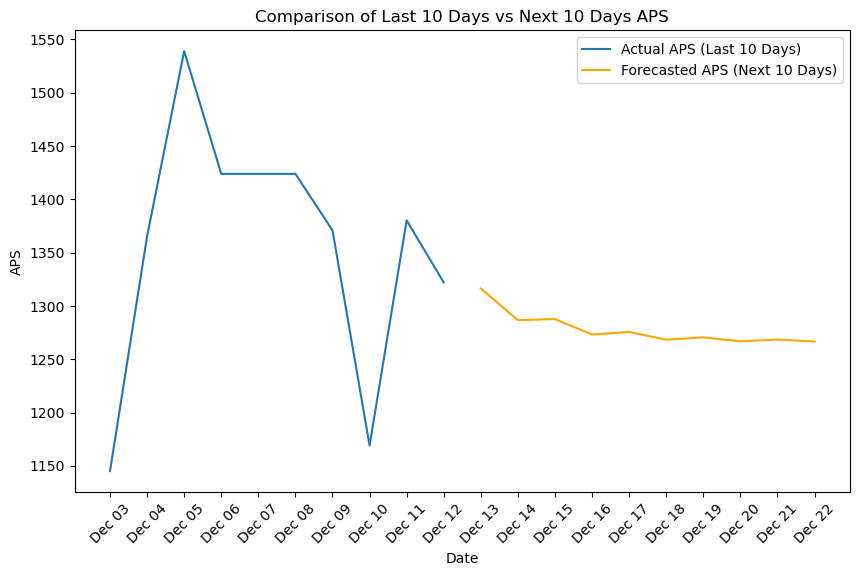

In [241]:
# Step 4: Plot the actual data and forecasted values
# Get the last 10 days from the actual data
last_10_days = aps_df.tail(10)

# Combine the last 10 days of actual data with the forecasted values
combined_df = pd.concat([last_10_days, forecast_df])

plt.figure(figsize=(10, 6))
plt.plot(last_10_days.index, last_10_days['APS'], label='Actual APS (Last 10 Days)')
plt.plot(forecast_df.index, forecast_df['Forecasted_APS'], label='Forecasted APS (Next 10 Days)', color='orange')
plt.xlabel('Date')
plt.ylabel('APS')
plt.title('Comparison of Last 10 Days vs Next 10 Days APS')

# Format the x-axis labels: rotate and only show month and day
plt.xticks(ticks=combined_df.index, labels=[label.strftime('%b %d') for label in combined_df.index], rotation=45)

plt.legend()
plt.show()

##### Evaluation

In [338]:
train_size = int(len(aps_df) * 0.8)
train_data, test_data = aps_df[:train_size], aps_df[train_size:]

# Fit the ARIMA model to the training data
model = sm.tsa.ARIMA(train_data['APS'], order=(2, 1, 2))  # Replace (p, d, q) with optimal values
model_fit = model.fit()

# Make predictions on the test data
forecast = model_fit.forecast(steps=len(test_data))

# Calculate MSE
mse = mean_squared_error(test_data['APS'], forecast)
print('Mean Squared Error:', mse)

# Calculate R-squared
y_true = test_data['APS']
y_pred = forecast
y_mean = np.mean(y_true)

# Calculate the squared residuals
ssr = np.sum((y_true - y_pred) ** 2)

# Calculate the total squared deviations from the mean
sst = np.sum((y_true - y_mean) ** 2)

# Calculate R-squared
r_squared = 1 - ssr / sst
print('R-squared:', r_squared)

C:\Users\Aniket Shinde\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Aniket Shinde\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Aniket Shinde\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Mean Squared Error: 42199.932282940266
R-squared: -0.19799535088276787


In [339]:
# Step 2: Use AutoSARIMA to find the best seasonal ARIMA parameters (p, d, q) and seasonal order (P, D, Q, s)
# s is the number of periods in each season, for daily data, s could be 5 if we think there’s weekly seasonality
sarima_model = pm.auto_arima(aps_df['APS'], seasonal=True, m=5, stepwise=True, trace=True, error_action='ignore', suppress_warnings=True)

# Print the best SARIMA model parameters
print(f"Best SARIMA model: {sarima_model.summary()}")

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[5] intercept   : AIC=67460.237, Time=12.99 sec
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=68573.372, Time=0.18 sec
 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=68203.928, Time=1.78 sec
 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=68038.529, Time=2.30 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=68571.415, Time=0.08 sec
 ARIMA(2,1,2)(0,0,1)[5] intercept   : AIC=67458.389, Time=9.38 sec
 ARIMA(2,1,2)(0,0,0)[5] intercept   : AIC=67463.468, Time=5.81 sec
 ARIMA(2,1,2)(0,0,2)[5] intercept   : AIC=67460.048, Time=15.92 sec
 ARIMA(2,1,2)(1,0,0)[5] intercept   : AIC=67458.292, Time=7.33 sec
 ARIMA(2,1,2)(2,0,0)[5] intercept   : AIC=67460.170, Time=14.03 sec
 ARIMA(2,1,2)(2,0,1)[5] intercept   : AIC=67461.899, Time=21.76 sec
 ARIMA(1,1,2)(1,0,0)[5] intercept   : AIC=67488.456, Time=6.74 sec
 ARIMA(2,1,1)(1,0,0)[5] intercept   : AIC=67486.357, Time=6.11 sec
 ARIMA(3,1,2)(1,0,0)[5] intercept   : AIC=67460.140, Time=12.38 sec
 ARIMA(2,1,3)(

In [340]:
# Step 3: Forecast the next 10 days using the best model
forecast_steps = 10
forecast = sarima_model.predict(n_periods=forecast_steps)

# Create a DateTime index for the next 10 days
last_date = aps_df.index[-1]
forecast_dates = pd.date_range(last_date, periods=forecast_steps + 1, freq='D')[1:]

# Create a DataFrame for the forecast results
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecasted_APS': forecast})
forecast_df.set_index('Date', inplace=True)

# Print the forecast
print(forecast_df)

                           Forecasted_APS
Date                                     
2024-12-13 00:00:00+00:00     1319.826171
2024-12-14 00:00:00+00:00     1285.479650
2024-12-15 00:00:00+00:00     1282.343019
2024-12-16 00:00:00+00:00     1273.015767
2024-12-17 00:00:00+00:00     1276.297838
2024-12-18 00:00:00+00:00     1266.357831
2024-12-19 00:00:00+00:00     1269.729728
2024-12-20 00:00:00+00:00     1263.814247
2024-12-21 00:00:00+00:00     1267.012002
2024-12-22 00:00:00+00:00     1263.643334


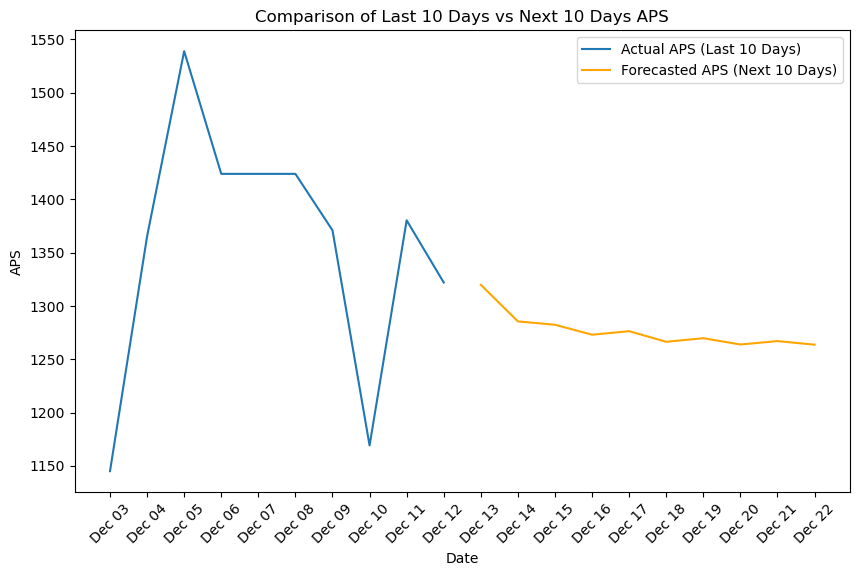

In [245]:
# Step 4: Plot the actual data and forecasted values
# Get the last 10 days from the actual data
last_10_days = aps_df.tail(10)

# Combine the last 10 days of actual data with the forecasted values
combined_df = pd.concat([last_10_days, forecast_df])

plt.figure(figsize=(10, 6))
plt.plot(last_10_days.index, last_10_days['APS'], label='Actual APS (Last 10 Days)')
plt.plot(forecast_df.index, forecast_df['Forecasted_APS'], label='Forecasted APS (Next 10 Days)', color='orange')
plt.xlabel('Date')
plt.ylabel('APS')
plt.title('Comparison of Last 10 Days vs Next 10 Days APS')

# Format the x-axis labels: rotate and only show month and day
plt.xticks(ticks=combined_df.index, labels=[label.strftime('%b %d') for label in combined_df.index], rotation=45)

plt.legend()
plt.show()

In [341]:
# Split the data into training and testing sets
train_size = int(len(aps_df) * 0.8)
train_data, test_data = aps_df[:train_size], aps_df[train_size:]

# Fit the SARIMA model to the training data
sarima_model = pm.auto_arima(train_data['APS'], seasonal=True, m=5, stepwise=True, trace=True, error_action='ignore', suppress_warnings=True)

# Make predictions on the test data
forecast = sarima_model.predict(len(test_data))

# Calculate MSE
mse = mean_squared_error(test_data['APS'], forecast)
print('Mean Squared Error:', mse)

# Calculate R-squared
y_true = test_data['APS']
y_pred = forecast
y_mean = np.mean(y_true)

# Calculate the squared residuals
ssr = np.sum((y_true - y_pred) ** 2)

# Calculate the total squared deviations from the mean
sst = np.sum((y_true - y_mean) ** 2)

# Calculate R-squared
r_squared = 1 - ssr / sst
print('R-squared:', r_squared)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[5] intercept   : AIC=50223.616, Time=12.71 sec
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=51007.637, Time=0.15 sec
 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=50723.380, Time=1.65 sec
 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=50617.470, Time=1.97 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=51005.733, Time=0.08 sec
 ARIMA(2,1,2)(0,0,1)[5] intercept   : AIC=50222.886, Time=8.10 sec
 ARIMA(2,1,2)(0,0,0)[5] intercept   : AIC=50220.903, Time=4.30 sec
 ARIMA(2,1,2)(1,0,0)[5] intercept   : AIC=50222.887, Time=5.78 sec
 ARIMA(1,1,2)(0,0,0)[5] intercept   : AIC=50230.361, Time=2.68 sec
 ARIMA(2,1,1)(0,0,0)[5] intercept   : AIC=50228.123, Time=3.37 sec
 ARIMA(3,1,2)(0,0,0)[5] intercept   : AIC=50222.891, Time=7.30 sec
 ARIMA(2,1,3)(0,0,0)[5] intercept   : AIC=50222.909, Time=4.26 sec
 ARIMA(1,1,1)(0,0,0)[5] intercept   : AIC=50245.218, Time=2.01 sec
 ARIMA(1,1,3)(0,0,0)[5] intercept   : AIC=50223.738, Time=4.49 sec
 ARIMA(3,1,1)(0,0,

In [246]:
final_data_scaled.columns

Index(['Adj Close', 'Adj Close Scaled', 'Close', 'High', 'Low', 'Open',
       'Volume', 'APS', 'Gold Price (INR)', 'USD to INR', 'S&P 500'],
      dtype='object')

In [254]:
final_data_scaled = final_data_scaled.rename(columns={'USD to INR': '1 USD (INR)'})

In [260]:
final_data_scaled

Adj Close        Close         High  \
Date                      Ticker                                              
2008-08-28 00:00:00+00:00 TCS.NS       152.424805   198.087494   206.062500   
                          INFY.NS      150.438522   212.425003   214.625000   
                          WIPRO.NS      37.649399    46.586250    48.588753   
                          HCLTECH.NS    38.026783    56.000000    58.750000   
                          TECHM.NS     137.753387   184.175003   195.975006   
...                                           ...          ...          ...   
2024-12-12 00:00:00+00:00 TCS.NS      4454.950195  4454.950195  4485.000000   
                          INFY.NS     1987.000000  1987.000000  1998.800049   
                          WIPRO.NS     309.100006   309.100006   313.799988   
                          HCLTECH.NS  1936.199951  1936.199951  1949.000000   
                          TECHM.NS    1789.599976  1789.599976  1807.699951   

                                              Low         Open      Volume  \
Date                      Ticker                                             
2008-08-28 00:00:00+00:00 TCS.NS       195.662506   205.000000   6580688.0   
                          INFY.NS      212.000000   214.125000  11480800.0   
                          WIPRO.NS      45.939377    48.037502  16700896.0   
                          HCLTECH.NS    55.287498    58.737499   4692348.0   
                          TECHM.NS     182.812500   193.750000    563212.0   
...                                           ...          ...         ...   
2024-12-12 00:00:00+00:00 TCS.NS      4426.000000  4430.049805   1914617.0   
                          INFY.NS     1970.550049  1975.199951   6461993.0   
                          WIPRO.NS     307.450012   308.000000  12956619.0   
                          HCLTECH.NS  1921.500000  1924.949951   2306151.0   
                          TECHM.NS    1761.050049  1768.050049   3017928.0   

                                              APS  Gold Price (INR)  \
Date                      Ticker                                      
2008-08-28 00:00:00+00:00 TCS.NS        90.334791      36268.787334   
                          INFY.NS       90.334791      36268.787334   
                          WIPRO.NS      90.334791      36268.787334   
                          HCLTECH.NS    90.334791      36268.787334   
                          TECHM.NS      90.334791      36268.787334   
...                                           ...               ...   
2024-12-12 00:00:00+00:00 TCS.NS      1321.980742     229522.542132   
                          INFY.NS     1321.980742     229522.542132   
                          WIPRO.NS    1321.980742     229522.542132   
                          HCLTECH.NS  1321.980742     229522.542132   
                          TECHM.NS    1321.980742     229522.542132   

                                      1 USD (INR)  S&P 500 (INR)  
Date                      Ticker                                  
2008-08-28 00:00:00+00:00 TCS.NS        43.650002   56774.686329  
                          INFY.NS       43.650002   56774.686329  
                          WIPRO.NS      43.650002   56774.686329  
                          HCLTECH.NS    43.650002   56774.686329  
                          TECHM.NS      43.650002   56774.686329  
...                                           ...            ...  
2024-12-12 00:00:00+00:00 TCS.NS        84.822998  515431.172215  
                          INFY.NS       84.822998  515431.172215  
                          WIPRO.NS      84.822998  515431.172215  
                          HCLTECH.NS    84.822998  515431.172215  
                          TECHM.NS      84.822998  515431.172215  

[29755 rows x 10 columns]

In [269]:
final_data_scaled.index

MultiIndex([('2008-08-28 00:00:00+00:00',     'TCS.NS'),
            ('2008-08-28 00:00:00+00:00',    'INFY.NS'),
            ('2008-08-28 00:00:00+00:00',   'WIPRO.NS'),
            ('2008-08-28 00:00:00+00:00', 'HCLTECH.NS'),
            ('2008-08-28 00:00:00+00:00',   'TECHM.NS'),
            ('2008-08-29 00:00:00+00:00',     'TCS.NS'),
            ('2008-08-29 00:00:00+00:00',    'INFY.NS'),
            ('2008-08-29 00:00:00+00:00',   'WIPRO.NS'),
            ('2008-08-29 00:00:00+00:00', 'HCLTECH.NS'),
            ('2008-08-29 00:00:00+00:00',   'TECHM.NS'),
            ...
            ('2024-12-11 00:00:00+00:00',     'TCS.NS'),
            ('2024-12-11 00:00:00+00:00',    'INFY.NS'),
            ('2024-12-11 00:00:00+00:00',   'WIPRO.NS'),
            ('2024-12-11 00:00:00+00:00', 'HCLTECH.NS'),
            ('2024-12-11 00:00:00+00:00',   'TECHM.NS'),
            ('2024-12-12 00:00:00+00:00',     'TCS.NS'),
            ('2024-12-12 00:00:00+00:00',    'INFY.NS'),
            ('2

In [276]:
print(final_data_scaled.head())

# Check the data types of the columns to confirm the structure of the DataFrame
print(final_data_scaled.dtypes)

# Check the index levels to confirm if 'Date' and 'Ticker' are in the index
print(final_data_scaled.index)

# Check the columns to see if 'Date', 'Ticker', and other relevant columns exist
print(final_data_scaled.columns)

                                       Adj Close       Close        High  \
Date                      Ticker                                           
2008-08-28 00:00:00+00:00 TCS.NS      152.424805  198.087494  206.062500   
                          INFY.NS     150.438522  212.425003  214.625000   
                          WIPRO.NS     37.649399   46.586250   48.588753   
                          HCLTECH.NS   38.026783   56.000000   58.750000   
                          TECHM.NS    137.753387  184.175003  195.975006   

                                             Low        Open      Volume  \
Date                      Ticker                                           
2008-08-28 00:00:00+00:00 TCS.NS      195.662506  205.000000   6580688.0   
                          INFY.NS     212.000000  214.125000  11480800.0   
                          WIPRO.NS     45.939377   48.037502  16700896.0   
                          HCLTECH.NS   55.287498   58.737499   4692348.0   
           

### RNN Models

#### GRU

##### Aggregating Data

In [291]:
# Step 1: Calculate the Total Volume per Date
total_volume_per_date = final_data_scaled.groupby('Date')['Volume'].sum()

# Step 2: Define a function to calculate the weighted aggregate for each column (Open, Close, High, Low)
def calculate_weighted_aggregate(group, column, total_volume):
    # Calculate the weight for each row
    group['Weight'] = group['Volume'] / total_volume
    # Compute the weighted aggregate sum
    weighted_aggregate = (group['Weight'] * group[column]).sum()
    return weighted_aggregate

# Step 3: Calculate the weighted aggregates for Open, Close, High, Low
aggregated_open = final_data_scaled.groupby('Date').apply(lambda group: calculate_weighted_aggregate(group, 'Open', total_volume_per_date[group.name]))
aggregated_close = final_data_scaled.groupby('Date').apply(lambda group: calculate_weighted_aggregate(group, 'Close', total_volume_per_date[group.name]))
aggregated_high = final_data_scaled.groupby('Date').apply(lambda group: calculate_weighted_aggregate(group, 'High', total_volume_per_date[group.name]))
aggregated_low = final_data_scaled.groupby('Date').apply(lambda group: calculate_weighted_aggregate(group, 'Low', total_volume_per_date[group.name]))

# Step 4: Aggregate the Volume using sum (since we are adding up the volumes)
aggregated_volume = final_data_scaled.groupby('Date')['Volume'].sum()

# Step 5: Extract the first value of APS, Gold Price (INR), 1 USD (INR), and S&P 500 (INR) for each date
aggregated_aps = final_data_scaled.groupby('Date')['APS'].first()
aggregated_gold_price = final_data_scaled.groupby('Date')['Gold Price (INR)'].first()
aggregated_usd_inr = final_data_scaled.groupby('Date')['1 USD (INR)'].first()
aggregated_sp500_inr = final_data_scaled.groupby('Date')['S&P 500 (INR)'].first()

# Step 6: Combine the aggregated results into a new DataFrame
aggregated_data = pd.DataFrame({
    'Open': aggregated_open,
    'Close': aggregated_close,
    'High': aggregated_high,
    'Low': aggregated_low,
    'Volume': aggregated_volume,
    'APS': aggregated_aps,
    'Gold Price (INR)': aggregated_gold_price,
    '1 USD (INR)': aggregated_usd_inr,
    'S&P 500 (INR)': aggregated_sp500_inr
}).reset_index()

In [292]:
aggregated_data

,Date,Open,Close,High,Low,Volume,APS,Gold Price (INR),1 USD (INR),S&P 500 (INR)
0,2008-08-28 00:00:00+00:00,124.803408,122.117572,125.384411,121.224185,40017944.0,90.334791,36268.787334,43.650002,56774.686329
1,2008-08-29 00:00:00+00:00,160.815515,164.376914,164.829385,160.613270,16657102.0,118.779990,36178.211967,43.625000,55963.456833
2,2008-08-30 00:00:00+00:00,189.250000,186.887497,189.250000,184.250000,1402980.0,118.779990,36178.211967,43.625000,55963.456833
3,2008-08-31 00:00:00+00:00,189.250000,186.887497,189.250000,184.250000,1402980.0,118.779990,36178.211967,43.625000,55963.456833
4,2008-09-01 00:00:00+00:00,189.250000,186.887497,189.250000,184.250000,1402980.0,118.779990,36178.211967,43.625000,55963.456833
...,...,...,...,...,...,...,...,...,...,...
5946,2024-12-08 00:00:00+00:00,1797.000000,1782.800049,1797.000000,1775.599976,5904200.0,1423.916884,223446.682274,84.683800,515747.206719
5947,2024-12-09 00:00:00+00:00,1364.560960,1370.943446,1378.054046,1354.294164,18075676.0,1370.943446,225626.416108,84.666000,512470.608585
5948,2024-12-10 00:00:00+00:00,1163.758752,1169.074821,1179.941761,1158.747107,29612049.0,1169.074821,228884.078476,84.847298,512045.818430
5949,2024-12-11 00:00:00+00:00,1374.763836,1380.336477,1384.578355,1368.547520,17942045.0,1380.336477,232028.546846,84.874001,516389.540429


In [302]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

##### Preprocessing + Training + Predicting

In [306]:
# Define the predict_future function
def predict_future(model, last_sequence, scaler, features, time_steps, days_to_predict):
    predicted_aps = []
    input_seq = last_sequence.reshape(1, time_steps, len(features))
    
    for _ in range(days_to_predict):
        # Predict the next APS value
        next_aps_scaled = model.predict(input_seq)
        
        # Inverse transform to get the actual APS value
        dummy_array = np.zeros((1, len(features)))
        dummy_array[0, -1] = next_aps_scaled[0, 0]
        next_aps_original = scaler.inverse_transform(dummy_array)[0, -1]
        
        predicted_aps.append(next_aps_original)
        
        # Prepare the input for the next prediction
        input_seq = np.roll(input_seq, -1, axis=1)
        input_seq[0, -1, :-1] = last_sequence[-1, :-1]  # Keep other features the same
        input_seq[0, -1, -1] = next_aps_scaled[0, 0]  # Use scaled prediction
    
    return np.array(predicted_aps)

# Create a separate scaler for the target variable
target_scaler = MinMaxScaler()
aggregated_data['APS_scaled'] = target_scaler.fit_transform(aggregated_data[['APS']])

# Modify the scaling process
features = ['Open', 'Close', 'High', 'Low', 'Volume', 'Gold Price (INR)', '1 USD (INR)', 'S&P 500 (INR)']
feature_scaler = MinMaxScaler()
scaled_features = feature_scaler.fit_transform(aggregated_data[features])

# Create a combined scaled dataset
scaled_data = np.column_stack([
    scaled_features, 
    aggregated_data['APS_scaled'].values
])

# Create sequences (rest of your existing sequence creation code remains the same)
def create_sequences(data, time_steps=60):
    X = []
    y = []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, :-1])  # Exclude last column (target)
        y.append(data[i, -1])  # Target value
    return np.array(X), np.array(y)

# Create sequences for training
time_steps = 60
X, y = create_sequences(scaled_data, time_steps)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Define the GRU Model
model = Sequential([
    GRU(units=64, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(units=1)
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Train with early stopping
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

model.fit(
    X_train, y_train, 
    epochs=50,
    batch_size=32, 
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

# Prepare the last sequence for prediction
last_sequence = scaled_data[-time_steps:, :-1]

# Make predictions
predicted_aps_scaled = predict_future(model, last_sequence, target_scaler, features, time_steps, 10)

# Inverse transform the predictions
predicted_aps_original = predicted_aps_scaled

print("Predicted APS values:", predicted_aps_original)

Epoch 1/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - loss: 0.0054 - val_loss: 0.0065
Epoch 2/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - loss: 0.0011 - val_loss: 0.0071
Epoch 3/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - loss: 0.0011 - val_loss: 0.0065
Epoch 4/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 0.0011 - val_loss: 0.0066
Epoch 5/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - loss: 0.0010 - val_loss: 0.0066
Epoch 6/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - loss: 0.0011 - val_loss: 0.0070
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicted APS values: [1271.0360255  1266.81078681 1256.12823337 1246.86703799 1240.15385948
 12

In [312]:
aggregated_data

,Date,Open,Close,High,Low,Volume,APS,Gold Price (INR),1 USD (INR),S&P 500 (INR),APS_scaled
1970-01-01 00:00:00.000000000,2008-08-28 00:00:00+00:00,124.803408,122.117572,125.384411,121.224185,40017944.0,90.334791,36268.787334,43.650002,56774.686329,0.026859
1970-01-01 00:00:00.000000001,2008-08-29 00:00:00+00:00,160.815515,164.376914,164.829385,160.613270,16657102.0,118.779990,36178.211967,43.625000,55963.456833,0.042663
1970-01-01 00:00:00.000000002,2008-08-30 00:00:00+00:00,189.250000,186.887497,189.250000,184.250000,1402980.0,118.779990,36178.211967,43.625000,55963.456833,0.042663
1970-01-01 00:00:00.000000003,2008-08-31 00:00:00+00:00,189.250000,186.887497,189.250000,184.250000,1402980.0,118.779990,36178.211967,43.625000,55963.456833,0.042663
1970-01-01 00:00:00.000000004,2008-09-01 00:00:00+00:00,189.250000,186.887497,189.250000,184.250000,1402980.0,118.779990,36178.211967,43.625000,55963.456833,0.042663
...,...,...,...,...,...,...,...,...,...,...,...
1970-01-01 00:00:00.000005946,2024-12-08 00:00:00+00:00,1797.000000,1782.800049,1797.000000,1775.599976,5904200.0,1423.916884,223446.682274,84.683800,515747.206719,0.767793
1970-01-01 00:00:00.000005947,2024-12-09 00:00:00+00:00,1364.560960,1370.943446,1378.054046,1354.294164,18075676.0,1370.943446,225626.416108,84.666000,512470.608585,0.738361
1970-01-01 00:00:00.000005948,2024-12-10 00:00:00+00:00,1163.758752,1169.074821,1179.941761,1158.747107,29612049.0,1169.074821,228884.078476,84.847298,512045.818430,0.626204
1970-01-01 00:00:00.000005949,2024-12-11 00:00:00+00:00,1374.763836,1380.336477,1384.578355,1368.547520,17942045.0,1380.336477,232028.546846,84.874001,516389.540429,0.743580


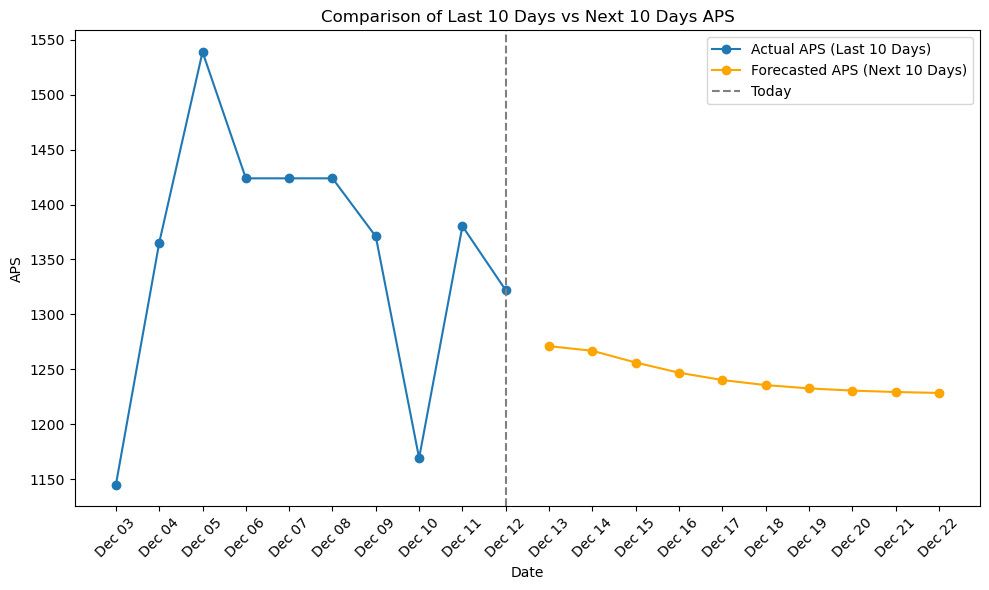

In [314]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure the 'Date' column is properly set as datetime
if 'Date' in aggregated_data.columns:
    aggregated_data['Date'] = pd.to_datetime(aggregated_data['Date'])
    aggregated_data.set_index('Date', inplace=True)

# Get the last 10 dates and actual APS values
last_10_actual = aggregated_data['APS'][-10:].values
last_10_dates = aggregated_data.index[-10:]

# Generate the next 10 dates for the forecast
last_date = last_10_dates[-1]
forecast_Ddates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=10)

# Combine the data
all_dates = list(last_10_dates) + list(forecast_dates)
all_values = list(last_10_actual) + list(predicted_aps_original)

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(last_10_dates, last_10_actual, label='Actual APS (Last 10 Days)', marker='o')
plt.plot(forecast_dates, predicted_aps_original, label='Forecasted APS (Next 10 Days)', marker='o', color='orange')
plt.axvline(last_date, color='gray', linestyle='--', label='Today')
plt.xlabel('Date')
plt.ylabel('APS')
plt.title('Comparison of Last 10 Days vs Next 10 Days APS')

# Format the x-axis: Show only month and day, rotated
formatted_dates = [date.strftime('%b %d') for date in all_dates]
plt.xticks(ticks=all_dates, labels=formatted_dates, rotation=45)

plt.legend()
plt.tight_layout()
plt.show()


In [315]:
aggregated_data

,Open,Close,High,Low,Volume,APS,Gold Price (INR),1 USD (INR),S&P 500 (INR),APS_scaled
Date,,,,,,,,,,
2008-08-28 00:00:00+00:00,124.803408,122.117572,125.384411,121.224185,40017944.0,90.334791,36268.787334,43.650002,56774.686329,0.026859
2008-08-29 00:00:00+00:00,160.815515,164.376914,164.829385,160.613270,16657102.0,118.779990,36178.211967,43.625000,55963.456833,0.042663
2008-08-30 00:00:00+00:00,189.250000,186.887497,189.250000,184.250000,1402980.0,118.779990,36178.211967,43.625000,55963.456833,0.042663
2008-08-31 00:00:00+00:00,189.250000,186.887497,189.250000,184.250000,1402980.0,118.779990,36178.211967,43.625000,55963.456833,0.042663
2008-09-01 00:00:00+00:00,189.250000,186.887497,189.250000,184.250000,1402980.0,118.779990,36178.211967,43.625000,55963.456833,0.042663
...,...,...,...,...,...,...,...,...,...,...
2024-12-08 00:00:00+00:00,1797.000000,1782.800049,1797.000000,1775.599976,5904200.0,1423.916884,223446.682274,84.683800,515747.206719,0.767793
2024-12-09 00:00:00+00:00,1364.560960,1370.943446,1378.054046,1354.294164,18075676.0,1370.943446,225626.416108,84.666000,512470.608585,0.738361
2024-12-10 00:00:00+00:00,1163.758752,1169.074821,1179.941761,1158.747107,29612049.0,1169.074821,228884.078476,84.847298,512045.818430,0.626204


##### Evaluation

In [324]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [325]:
# Perform train-test split on the entire dataset
train_size = int(len(aggregated_data) * 0.8)
train_data = aggregated_data[:train_size]
test_data = aggregated_data[train_size:]

# Create separate scalers for training data
target_scaler = MinMaxScaler()
feature_scaler = MinMaxScaler()

# Scale training features
train_features = ['Open', 'Close', 'High', 'Low', 'Volume', 'Gold Price (INR)', '1 USD (INR)', 'S&P 500 (INR)']
train_scaled_features = feature_scaler.fit_transform(train_data[train_features])
train_scaled_target = target_scaler.fit_transform(train_data[['APS']])

# Combine scaled training data
train_scaled_data = np.column_stack([
    train_scaled_features, 
    train_scaled_target
])

# Create training sequences
time_steps = 60
X_train, y_train = create_sequences(train_scaled_data, time_steps)

# Scale test features using the same scalers
test_scaled_features = feature_scaler.transform(test_data[train_features])
test_scaled_target = target_scaler.transform(test_data[['APS']])

# Combine scaled test data
test_scaled_data = np.column_stack([
    test_scaled_features, 
    test_scaled_target
])

# Create test sequences
X_test, y_test = create_sequences(test_scaled_data, time_steps)

# Define the GRU Model
model = Sequential([
    GRU(units=64, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(units=1)
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Train with early stopping
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

model.fit(
    X_train, y_train, 
    epochs=50,
    batch_size=32, 
    validation_split=0.2,  # Use validation split instead of separate test data
    callbacks=[early_stopping]
)

# Evaluation function
def evaluate_model(model, X_test, y_test, target_scaler):
    # Predict
    y_pred_scaled = model.predict(X_test)
    y_pred = target_scaler.inverse_transform(y_pred_scaled)
    y_test_original = target_scaler.inverse_transform(y_test.reshape(-1, 1))

    # Calculate metrics
    mse = mean_squared_error(y_test_original, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_original, y_pred)
    mape = np.mean(np.abs((y_test_original - y_pred) / y_test_original)) * 100
    r2 = r2_score(y_test_original, y_pred)

    print("Model Evaluation Metrics:")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"MAE: {mae}")
    print(f"MAPE: {mape}%")
    print(f"R-squared: {r2}")

    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'R-squared': r2
    }

# Evaluate the model
metrics = evaluate_model(model, X_test, y_test, target_scaler)

Epoch 1/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - loss: 0.0026 - val_loss: 0.0062
Epoch 2/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - loss: 0.0010 - val_loss: 0.0054
Epoch 3/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - loss: 0.0011 - val_loss: 0.0058
Epoch 4/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - loss: 0.0011 - val_loss: 0.0054
Epoch 5/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - loss: 0.0010 - val_loss: 0.0054
Epoch 6/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - loss: 9.9759e-04 - val_loss: 0.0055
Epoch 7/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - loss: 9.7045e-04 - val_loss: 0.0053
Epoch 8/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - loss: 9.8411e-04 - val_loss: 0.0054
Epoch 9/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - loss: 9.2687e-04 - val_loss: 0.0053
Epoch 10/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - loss: 0.0012 - val_loss: 0.0051
Epoch 11/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - loss: 0.0011 - val_loss: 0.0050
Epoch 12/50
118/118 ━━

#### LSTM

In [327]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

##### Preprocessing + Training

In [328]:
# Define the predict_future function for LSTM
def predict_future_lstm(model, last_sequence, scaler, features, time_steps, days_to_predict):
    predicted_aps = []
    input_seq = last_sequence.reshape(1, time_steps, len(features))

    for _ in range(days_to_predict):
        # Predict the next APS value
        next_aps_scaled = model.predict(input_seq)

        # Inverse transform to get the actual APS value
        dummy_array = np.zeros((1, len(features)))
        dummy_array[0, -1] = next_aps_scaled[0, 0]
        next_aps_original = scaler.inverse_transform(dummy_array)[0, -1]

        predicted_aps.append(next_aps_original)

        # Prepare the input for the next prediction
        input_seq = np.roll(input_seq, -1, axis=1)
        input_seq[0, -1, :-1] = last_sequence[-1, :-1]  # Keep other features the same
        input_seq[0, -1, -1] = next_aps_scaled[0, 0]  # Use scaled prediction

    return np.array(predicted_aps)

# Create a separate scaler for the target variable
target_scaler = MinMaxScaler()
aggregated_data['APS_scaled'] = target_scaler.fit_transform(aggregated_data[['APS']])

# Modify the scaling process
features = ['Open', 'Close', 'High', 'Low', 'Volume', 'Gold Price (INR)', '1 USD (INR)', 'S&P 500 (INR)']
feature_scaler = MinMaxScaler()
scaled_features = feature_scaler.fit_transform(aggregated_data[features])

# Create a combined scaled dataset
scaled_data = np.column_stack([
    scaled_features, 
    aggregated_data['APS_scaled'].values
])

# Create sequences
def create_sequences(data, time_steps=60):
    X = []
    y = []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, :-1])  # Exclude last column (target)
        y.append(data[i, -1])  # Target value
    return np.array(X), np.array(y)

# Create sequences for training
time_steps = 60
X, y = create_sequences(scaled_data, time_steps)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Define the LSTM Model
model = Sequential([
    LSTM(units=64, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(units=1)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train with early stopping
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

model.fit(
    X_train, y_train, 
    epochs=50,
    batch_size=32, 
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

Epoch 1/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - loss: 0.0033 - val_loss: 0.0076
Epoch 2/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - loss: 0.0011 - val_loss: 0.0077
Epoch 3/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - loss: 0.0011 - val_loss: 0.0090
Epoch 4/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - loss: 0.0010 - val_loss: 0.0069
Epoch 5/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - loss: 0.0010 - val_loss: 0.0099
Epoch 6/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - loss: 0.0010 - val_loss: 0.0067
Epoch 7/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - loss: 0.0011 - val_loss: 0.0065
Epoch 8/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - loss: 9.8915e-04 - val_loss: 0.0069
Epoch 9/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - loss: 9.1604e-04 - val_loss: 0.0064
Epoch 10/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - loss: 0.0011 - val_loss: 0.0069
Epoch 11/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - loss: 0.0010 - val_loss: 0.0077
Epoch 12/50
148/148 ━━

##### Predicting

In [329]:
# Prepare the last sequence for prediction
last_sequence = scaled_data[-time_steps:, :-1]

# Make predictions
predicted_aps_scaled = predict_future_lstm(model, last_sequence, target_scaler, features, time_steps, 10)

# Inverse transform the predictions
predicted_aps_original = predicted_aps_scaled

print("Predicted APS values:", predicted_aps_original)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 502ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Predicted APS values: [1311.57922096 1279.73292595 1258.8954241  1241.99200191 1228.63484073
 1218.41187654 1210.81535118 1205.33235704 1201.49858455 1198.91634524]


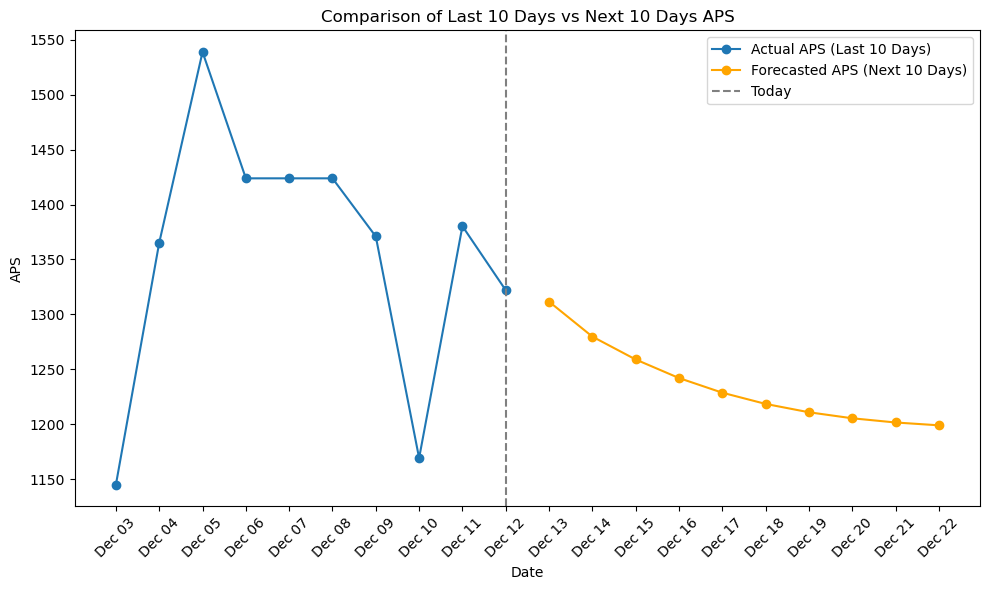

In [331]:
# Ensure the 'Date' column is properly set as datetime
if 'Date' in aggregated_data.columns:
    aggregated_data['Date'] = pd.to_datetime(aggregated_data['Date'])
    aggregated_data.set_index('Date', inplace=True)

# Get the last 10 dates and actual APS values
last_10_actual = aggregated_data['APS'][-10:].values
last_10_dates = aggregated_data.index[-10:]

# Generate the next 10 dates for the forecast
last_date = last_10_dates[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=10)

# Combine the data
all_dates = list(last_10_dates) + list(forecast_dates)
all_values = list(last_10_actual) + list(predicted_aps_original)

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(last_10_dates, last_10_actual, label='Actual APS (Last 10 Days)', marker='o')
plt.plot(forecast_dates, predicted_aps_original, label='Forecasted APS (Next 10 Days)', marker='o', color='orange')
plt.axvline(last_date, color='gray', linestyle='--', label='Today')
plt.xlabel('Date')
plt.ylabel('APS')
plt.title('Comparison of Last 10 Days vs Next 10 Days APS')

# Format the x-axis: Show only month and day, rotated
formatted_dates = [date.strftime('%b %d') for date in all_dates]
plt.xticks(ticks=all_dates, labels=formatted_dates, rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

##### Evaluation

In [1]:
y_pred = model.predict(X_test)
y_pred_original = target_scaler.inverse_transform(
    np.column_stack([np.zeros((y_pred.shape[0], len(features))), y_pred])
)[:, -1]
y_test_original = target_scaler.inverse_transform(
    np.column_stack([np.zeros((y_test.shape[0], len(features))), y_test.reshape(-1, 1)])
)[:, -1]

mse = mean_squared_error(y_test_original, y_pred_original)
mae = mean_absolute_error(y_test_original, y_pred_original)
mape = mean_absolute_percentage_error(y_test_original, y_pred_original)
r2 = r2_score(y_test_original, y_pred_original)

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Mean Absolute Percentage Error (MAPE):", mape * 100)
print("R^2 Score:", r2)

NameError: name 'model' is not defined